# Bank Cash Optimization: Forecasting Half-Daily Branch Cash Demand

This notebook forecasts how much cash each of 15 bank branches will pay out (total debit) in the morning and in the afternoon of each day. With a reliable forecast the bank can plan vault replenishment ahead of time, avoiding both cash shortages and large amounts of idle cash.

**Data.** 81,717 hourly transaction records (2 Jan 2024 to 4 Apr 2026), aggregated to AM and PM totals per branch.

**Models compared.** A rolling-mean baseline, Prophet, LightGBM, and a tuned XGBoost + LightGBM ensemble, which is the final model.

**Evaluation.** The last 20% of dates (3,457 rows, 29 Oct 2025 to 4 Apr 2026) is held out. Inside the training period we use 5-fold rolling-origin cross-validation. All errors are measured against the raw actuals, before outlier capping.

**Results for the final model (debit):**

| | Cross-validation | Hold-out |
|---|---|---|
| R² | 0.581 ± 0.066 | 0.401 |
| MAE | 9.77M ± 0.66M PKR | 11.46M PKR |
| WMAPE | 39.5% ± 2.4% | 44.9% |

The notebook runs from top to bottom on a fresh Colab runtime: it installs its packages, downloads the data from Google Drive and trains every model from scratch. The same training setup is available as a script (`src/v3_pipeline.py` in the project repository), which is where the tuned hyperparameters in Section 6.4 come from.

## Follow-up on the August 2026 review

| Review point | Where it is answered |
|---|---|
| Explain why MAPE is unreliable on this data | Section 6, "MAPE vs WMAPE" |
| Verify the ensemble blending and SHAP instead of assuming them | Section 8.1 |
| Check per-branch performance, especially branches 202 and 1739, and whether the fold-to-fold variance comes from a few branches | Section 7.0 |

Short answers:

- **Branch 202** is one of the better branches (R² 0.66, WMAPE 32.7%, 3rd of 15). Its high MAPE comes from a few half-days with near-zero demand.
- **Branch 1739** is weak (R² 0.36, WMAPE 48.0%, 14th of 15), so the concern was justified. **Branch 104**, which was not flagged, is the weakest (WMAPE 50.2%) and accounts for 24% of the total forecast error.
- **Is the variance concentrated?** For WMAPE, no: removing the five worst branches still leaves 72% of the fold-to-fold spread. For R², mostly yes: branch 104 alone accounts for about half of the R² spread, because it is much larger than the other branches and R² is computed on the pooled data.
- **Branch-level tuning or more data?** Neither looks like the answer. Separate per-branch models were worse for all 15 branches, and the amount of history per branch shows no clear link with accuracy. The branches that are hard to forecast are the ones with the most volatile demand.

Answering the per-branch question turned up five problems in the evaluation code and one in the forecast code. All six are fixed and listed at the end of Section 7.0. While rewriting Section 6 we also fixed the baseline and Prophet scores: they are now measured against the raw actuals like the other models, and Prophet's predictions are matched to the test rows by timestamp (its `predict()` returns rows sorted by time, which had put them out of line with the test rows).

---
# 1. Setup
Install the packages that are not preinstalled on Colab.

In [1]:
%%capture
!pip install xgboost lightgbm shap openpyxl prophet

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from prophet import Prophet
import shap

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

---
# 2. Data loading

The dataset is a Google Sheet on Google Drive. Downloading it through the sheet's export link means anyone with the share link can run the notebook without mounting Drive.

In [3]:
file_id = "14rQekYAWPpJBd5vJP1HG_RyF7NUj2U0s"
url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=xlsx"
urllib.request.urlretrieve(url, "bank_cash_data.xlsx")

df = pd.read_excel("bank_cash_data.xlsx")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (81717, 5)


,start_date,txn_hour,tran_br_code,TOTAL_DR,TOTAL_CR
0,2026-03-07,14,1046,14400000,10971992
1,2024-11-12,13,1046,16280280,7700344
2,2025-05-15,15,287,8700118,6046617
3,2025-08-20,13,1092,6688531,4895120
4,2024-11-22,13,202,0,10969592


In [4]:
# start_date, txn_hour, tran_br_code, TOTAL_DR (cash paid out), TOTAL_CR (cash received)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81717 entries, 0 to 81716
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   start_date    81717 non-null  datetime64[us]
 1   txn_hour      81717 non-null  int64         
 2   tran_br_code  81717 non-null  int64         
 3   TOTAL_DR      81717 non-null  int64         
 4   TOTAL_CR      81717 non-null  int64         
dtypes: datetime64[us](1), int64(4)
memory usage: 3.1 MB


---
# 3. Exploratory data analysis

In [5]:
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

start_date      0
txn_hour        0
tran_br_code    0
TOTAL_DR        0
TOTAL_CR        0
dtype: int64

Total missing values: 0


In [6]:
df.describe()

,start_date,txn_hour,tran_br_code,TOTAL_DR,TOTAL_CR
count,81717,81717.000000,81717.000000,8.171700e+04,8.171700e+04
mean,2025-02-16 12:20:59.781930,13.242924,738.220113,5.664091e+06,5.657968e+06
min,2024-01-02 00:00:00,0.000000,104.000000,0.000000e+00,0.000000e+00
25%,2024-07-31 00:00:00,11.000000,287.000000,4.162230e+05,8.855120e+05
50%,2025-02-13 00:00:00,13.000000,593.000000,1.645828e+06,2.482750e+06
75%,2025-09-11 00:00:00,16.000000,1200.000000,6.395170e+06,5.770690e+06
max,2026-04-04 00:00:00,23.000000,1739.000000,8.586383e+08,8.619220e+08
std,NaN,2.830673,488.490070,1.457346e+07,1.450989e+07


In [7]:
# date parts used in the plots below
df['start_date'] = pd.to_datetime(df['start_date'])
df['Weekday'] = df['start_date'].dt.dayofweek          # 0 = Monday, 6 = Sunday
df['Is_Weekend'] = (df['Weekday'] >= 5).astype(int)
df['Day'] = df['start_date'].dt.day

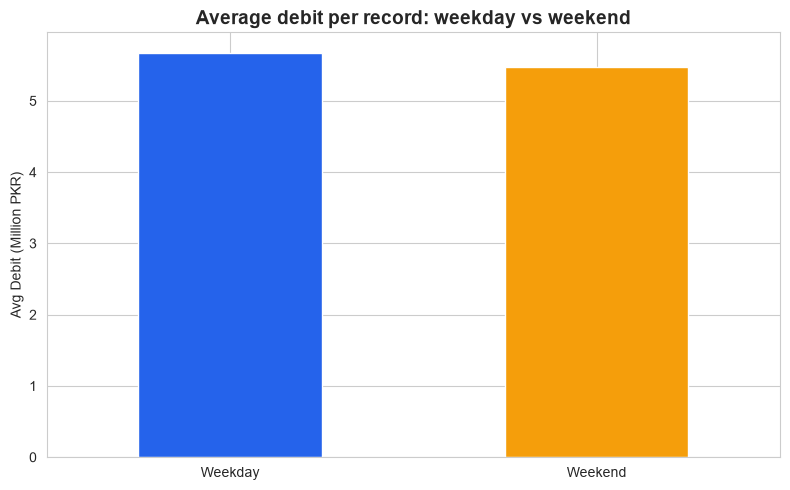

In [8]:
# weekday vs weekend
fig, ax = plt.subplots(figsize=(8, 5))
day_type = df.groupby('Is_Weekend')['TOTAL_DR'].mean() / 1e6
day_type.index = ['Weekday', 'Weekend']
day_type.plot.bar(ax=ax, color=['#2563eb', '#f59e0b'], edgecolor='white')
ax.set_title('Average debit per record: weekday vs weekend', fontsize=14, weight='bold')
ax.set_ylabel('Avg Debit (Million PKR)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

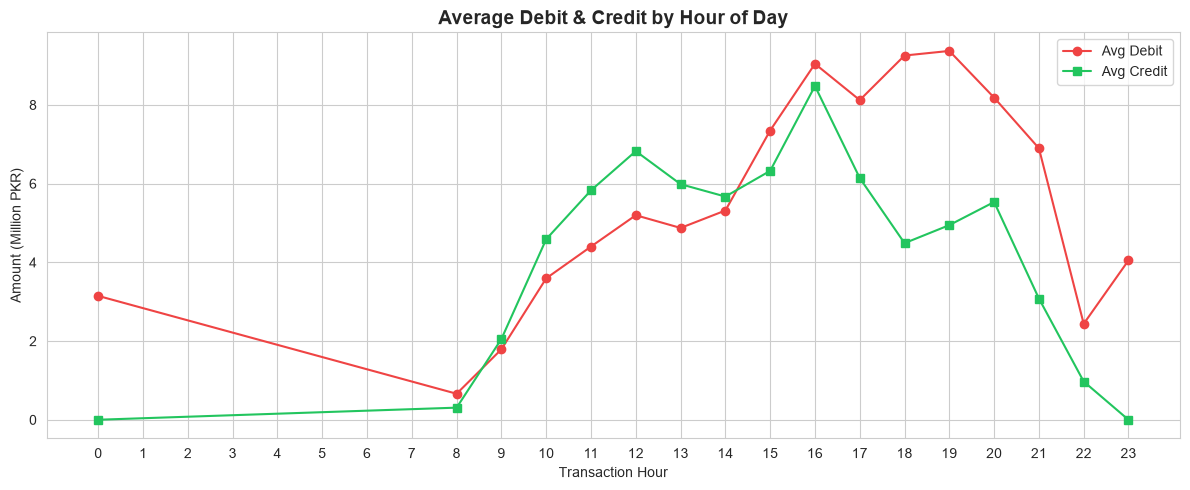

In [9]:
# average debit and credit by hour
hourly = df.groupby('txn_hour')[['TOTAL_DR', 'TOTAL_CR']].mean() / 1e6

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly.index, hourly['TOTAL_DR'], marker='o', label='Avg Debit', color='#ef4444')
ax.plot(hourly.index, hourly['TOTAL_CR'], marker='s', label='Avg Credit', color='#22c55e')
ax.set_title('Average Debit & Credit by Hour of Day', fontsize=14, weight='bold')
ax.set_xlabel('Transaction Hour')
ax.set_ylabel('Amount (Million PKR)')
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

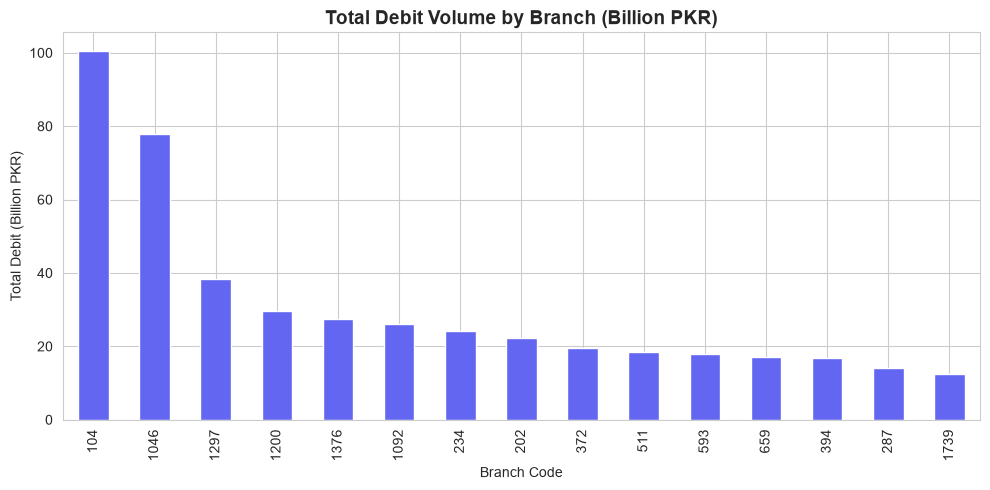

In [10]:
# total debit by branch
branch_vol = df.groupby('tran_br_code')['TOTAL_DR'].sum().sort_values(ascending=False) / 1e9

fig, ax = plt.subplots(figsize=(10, 5))
branch_vol.plot.bar(ax=ax, color='#6366f1', edgecolor='white')
ax.set_title('Total Debit Volume by Branch (Billion PKR)', fontsize=14, weight='bold')
ax.set_ylabel('Total Debit (Billion PKR)')
ax.set_xlabel('Branch Code')
plt.tight_layout()
plt.show()

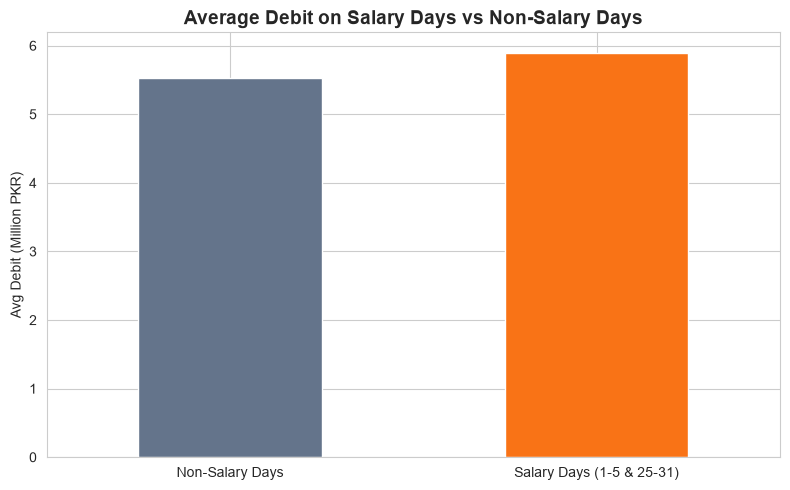

In [11]:
# salary days (1st-5th and 25th-31st) vs other days
df['Is_Salary_Day_EDA'] = ((df['Day'] <= 5) | (df['Day'] >= 25)).astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
salary_avg = df.groupby('Is_Salary_Day_EDA')['TOTAL_DR'].mean() / 1e6
salary_avg.index = ['Non-Salary Days', 'Salary Days (1-5 & 25-31)']
salary_avg.plot.bar(ax=ax, color=['#64748b', '#f97316'], edgecolor='white')
ax.set_title('Average Debit on Salary Days vs Non-Salary Days', fontsize=14, weight='bold')
ax.set_ylabel('Avg Debit (Million PKR)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

df.drop(columns=['Is_Salary_Day_EDA'], inplace=True)

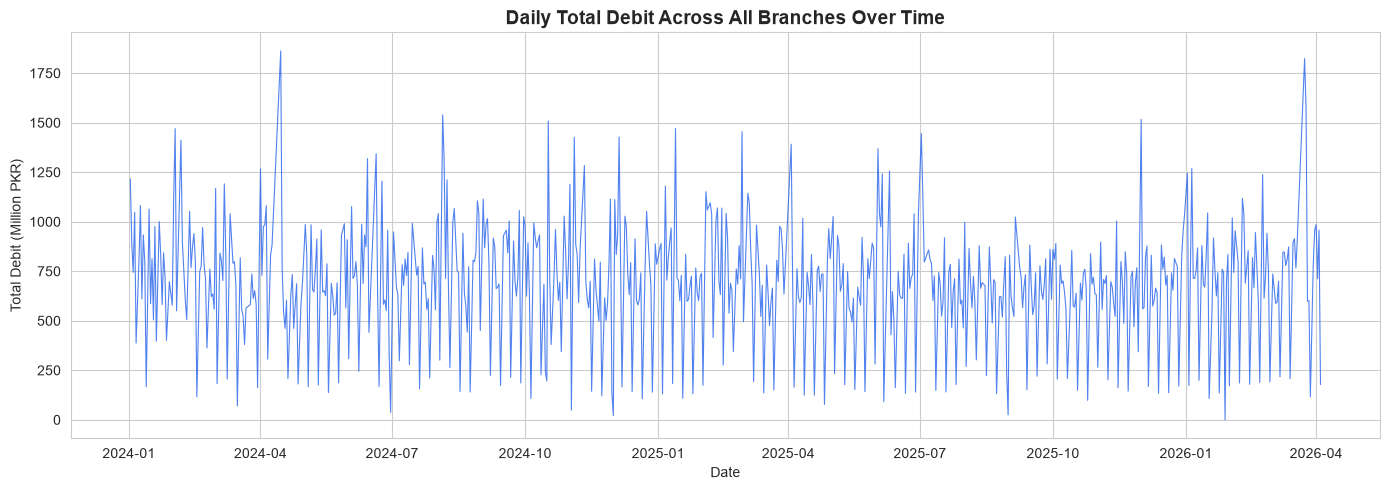

In [12]:
# total debit per day, all branches
daily_total = df.groupby('start_date')['TOTAL_DR'].sum() / 1e6

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_total.index, daily_total.values, linewidth=0.8, color='#2563eb', alpha=0.8)
ax.set_title('Daily Total Debit Across All Branches Over Time', fontsize=14, weight='bold')
ax.set_ylabel('Total Debit (Million PKR)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

---
# 4. Preprocessing and feature engineering

## 4.1 Half-daily (AM / PM) aggregation

The hourly records are summed into two periods per day for each branch:
- AM: `txn_hour < 12`
- PM: `txn_hour >= 12`

Half-day totals are much less noisy than hourly ones, but unlike daily totals they still show the difference between morning and afternoon demand.

In [13]:
df['AM_PM'] = np.where(df['txn_hour'] < 12, 'AM', 'PM')

half_daily = df.groupby(['start_date', 'AM_PM', 'tran_br_code']).agg(
    Half_Day_Total_Debit  = ('TOTAL_DR', 'sum'),
    Half_Day_Total_Credit = ('TOTAL_CR', 'sum'),
    Txn_Count             = ('TOTAL_DR', 'count'),
    Weekday               = ('Weekday', 'first'),
    Is_Weekend            = ('Is_Weekend', 'first'),
    Month                 = ('start_date', lambda x: x.dt.month.iloc[0]),
    Day                   = ('start_date', lambda x: x.dt.day.iloc[0]),
).reset_index()

half_daily['Half_Day_Net_Cash'] = half_daily['Half_Day_Total_Credit'] - half_daily['Half_Day_Total_Debit']
half_daily['AM_PM_Encoded'] = np.where(half_daily['AM_PM'] == 'AM', 0, 1)

# keep the uncapped debit; all evaluation is done against this column
half_daily['Half_Day_Total_Debit_RAW'] = half_daily['Half_Day_Total_Debit']

# Cap outliers at each branch's 99th percentile, using only the first 80% of that branch's rows
# (roughly its training period) so the test period does not affect the cap.
# SeriesGroupBy.apply keeps tran_br_code; DataFrameGroupBy.apply drops it in pandas 3.
_caps = half_daily.groupby('tran_br_code')['Half_Day_Total_Debit'].apply(
    lambda s: s.iloc[:int(len(s) * 0.8)].quantile(0.99)
)
half_daily['Half_Day_Total_Debit'] = half_daily['Half_Day_Total_Debit'].clip(
    upper=half_daily['tran_br_code'].map(_caps)
)
print(f"Capped {int((half_daily['Half_Day_Total_Debit'] < half_daily['Half_Day_Total_Debit_RAW']).sum())} "
      f"outlier rows across {half_daily['tran_br_code'].nunique()} branches.")
print(f"Half-daily records: {len(half_daily)}")
half_daily.head()

Capped 214 outlier rows across 15 branches.
Half-daily records: 18017


,start_date,AM_PM,tran_br_code,Half_Day_Total_Debit,Half_Day_Total_Credit,Txn_Count,Weekday,Is_Weekend,Month,Day,Half_Day_Net_Cash,AM_PM_Encoded,Half_Day_Total_Debit_RAW
0,2024-01-02,AM,104,154431545.0,134968616,3,1,0,1,2,-19462929,0,154431545
1,2024-01-02,AM,202,10276193.0,3471987,3,1,0,1,2,-6804206,0,10276193
2,2024-01-02,AM,234,7500176.0,9660658,3,1,0,1,2,2160482,0,7500176
3,2024-01-02,AM,287,2608848.0,4360900,3,1,0,1,2,1752052,0,2608848
4,2024-01-02,AM,372,5979171.0,7815115,3,1,0,1,2,1835944,0,5979171


## 4.2 Calendar features

Salary window (1st to 5th and 25th to 31st of the month), Pakistani public holidays, the distance to and from the salary window, and month start/end flags.

In [14]:
# salary window: 1st-5th and 25th-31st of each month
half_daily['Is_Salary_Day'] = ((half_daily['Day'] <= 5) | (half_daily['Day'] >= 25)).astype(int)

# Pakistan public holidays, 2024-2026
pk_holidays = pd.to_datetime([
    # 2024
    '2024-02-05', '2024-03-23', '2024-04-10', '2024-04-11', '2024-04-12', '2024-05-01',
    '2024-06-17', '2024-06-18', '2024-06-19', '2024-07-16', '2024-07-17', '2024-08-14',
    '2024-09-16', '2024-11-09', '2024-12-25',
    # 2025
    '2025-02-05', '2025-03-23', '2025-03-31', '2025-04-01', '2025-04-02', '2025-05-01',
    '2025-06-06', '2025-06-07', '2025-06-08', '2025-07-05', '2025-07-06', '2025-08-14',
    '2025-09-05', '2025-11-09', '2025-12-25',
    # 2026
    '2026-02-05', '2026-03-20', '2026-03-21', '2026-03-22', '2026-03-23', '2026-05-01',
    '2026-05-27', '2026-05-28', '2026-05-29', '2026-06-25', '2026-06-26', '2026-08-14',
    '2026-08-26', '2026-11-09', '2026-12-25',
])
half_daily['Is_Holiday'] = half_daily['start_date'].isin(pk_holidays).astype(int)

# days to the next salary window and since the last one
half_daily['Days_to_Salary'] = half_daily['Day'].apply(lambda d: 25 - d if d < 25 else (31 - d + 5))
half_daily['Days_to_Salary'] = half_daily['Days_to_Salary'].clip(lower=0, upper=25)
half_daily['Days_Since_Salary'] = half_daily['Day'].apply(lambda d: d - 25 if d >= 25 else d + (31 - 25))
half_daily['Is_Month_Start'] = half_daily['start_date'].dt.is_month_start.astype(int)
half_daily['Is_Month_End'] = half_daily['start_date'].dt.is_month_end.astype(int)

print("Added: Is_Salary_Day, Is_Holiday, Days_to_Salary, Days_Since_Salary, Is_Month_Start, Is_Month_End")
half_daily[['start_date', 'AM_PM', 'tran_br_code', 'Weekday', 'Is_Weekend',
            'Month', 'Day', 'Is_Salary_Day', 'Is_Holiday', 'Days_to_Salary', 'Days_Since_Salary', 'Is_Month_Start', 'Is_Month_End']].head(10)

Added: Is_Salary_Day, Is_Holiday, Days_to_Salary, Days_Since_Salary, Is_Month_Start, Is_Month_End


,start_date,AM_PM,tran_br_code,Weekday,Is_Weekend,Month,Day,Is_Salary_Day,Is_Holiday,Days_to_Salary,Days_Since_Salary,Is_Month_Start,Is_Month_End
0,2024-01-02,AM,104,1,0,1,2,1,0,23,8,0,0
1,2024-01-02,AM,202,1,0,1,2,1,0,23,8,0,0
2,2024-01-02,AM,234,1,0,1,2,1,0,23,8,0,0
3,2024-01-02,AM,287,1,0,1,2,1,0,23,8,0,0
4,2024-01-02,AM,372,1,0,1,2,1,0,23,8,0,0
5,2024-01-02,AM,394,1,0,1,2,1,0,23,8,0,0
6,2024-01-02,AM,511,1,0,1,2,1,0,23,8,0,0
7,2024-01-02,AM,593,1,0,1,2,1,0,23,8,0,0
8,2024-01-02,AM,659,1,0,1,2,1,0,23,8,0,0
9,2024-01-02,AM,1046,1,0,1,2,1,0,23,8,0,0


## 4.3 Lag and rolling features

All lags and rolling windows are computed per branch on values shifted by at least one step, so a row never uses its own target value. Steps are half-days: a lag of 2 is one day, 14 is one week and 60 is about a month.

In [15]:
half_daily = half_daily.sort_values(["tran_br_code", "start_date", "AM_PM"]).reset_index(drop=True)

for target in ["Half_Day_Total_Debit", "Half_Day_Total_Credit", "Half_Day_Net_Cash"]:
    half_daily[f"lag_1_{target}"]  = half_daily.groupby("tran_br_code")[target].shift(1)
    half_daily[f"lag_2_{target}"]  = half_daily.groupby("tran_br_code")[target].shift(2)
    half_daily[f"lag_14_{target}"] = half_daily.groupby("tran_br_code")[target].shift(14)
    half_daily[f"lag_60_{target}"] = half_daily.groupby("tran_br_code")[target].shift(60)
    half_daily[f"rolling_14_std_{target}"] = half_daily.groupby("tran_br_code")[target].transform(
        lambda x: x.shift(1).rolling(14, min_periods=2).std()
    ).fillna(0)
    half_daily[f"rolling_14_mean_{target}"] = half_daily.groupby("tran_br_code")[target].transform(
        lambda x: x.shift(1).rolling(14, min_periods=1).mean()
    ).fillna(0)
    half_daily[f"ewma_14_{target}"] = half_daily.groupby("tran_br_code")[target].transform(
        lambda x: x.shift(1).ewm(span=14, adjust=False).mean()
    ).fillna(0)
    # mean of the last 4 half-days with the same weekday and AM/PM slot
    half_daily[f"dow_avg_4_{target}"] = half_daily.groupby(["tran_br_code", "Weekday", "AM_PM"])[target].transform(
        lambda x: x.shift(1).rolling(4, min_periods=1).mean()
    ).fillna(0)

# drop the first 60 rows of each branch, where lag_60 is missing
before = len(half_daily)
half_daily = half_daily.dropna(subset=["lag_60_Half_Day_Total_Debit"]).reset_index(drop=True)

# previous transaction counts (the current count is not known in advance)
half_daily["lag_1_Txn_Count"] = half_daily.groupby("tran_br_code")["Txn_Count"].shift(1)
half_daily["rolling_14_mean_Txn_Count"] = half_daily.groupby("tran_br_code")["Txn_Count"].transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())
half_daily["lag_1_Txn_Count"] = half_daily["lag_1_Txn_Count"].fillna(0)
half_daily["rolling_14_mean_Txn_Count"] = half_daily["rolling_14_mean_Txn_Count"].fillna(0)
half_daily["ewma_14_Txn_Count"] = half_daily.groupby("tran_br_code")["Txn_Count"].transform(lambda x: x.shift(1).ewm(span=14, adjust=False).mean()).fillna(0)

print(f"Dropped {before - len(half_daily)} warm-up rows. {len(half_daily)} usable records remaining.")

Dropped 900 warm-up rows. 17117 usable records remaining.


In [16]:
import os
os.makedirs('data/processed', exist_ok=True)
half_daily.to_csv('data/processed/half_daily_features.csv', index=False)
print(f"Saved data/processed/half_daily_features.csv, shape {half_daily.shape}")
print(list(half_daily.columns))

Saved data/processed/half_daily_features.csv, shape (17117, 46)
['start_date', 'AM_PM', 'tran_br_code', 'Half_Day_Total_Debit', 'Half_Day_Total_Credit', 'Txn_Count', 'Weekday', 'Is_Weekend', 'Month', 'Day', 'Half_Day_Net_Cash', 'AM_PM_Encoded', 'Half_Day_Total_Debit_RAW', 'Is_Salary_Day', 'Is_Holiday', 'Days_to_Salary', 'Days_Since_Salary', 'Is_Month_Start', 'Is_Month_End', 'lag_1_Half_Day_Total_Debit', 'lag_2_Half_Day_Total_Debit', 'lag_14_Half_Day_Total_Debit', 'lag_60_Half_Day_Total_Debit', 'rolling_14_std_Half_Day_Total_Debit', 'rolling_14_mean_Half_Day_Total_Debit', 'ewma_14_Half_Day_Total_Debit', 'dow_avg_4_Half_Day_Total_Debit', 'lag_1_Half_Day_Total_Credit', 'lag_2_Half_Day_Total_Credit', 'lag_14_Half_Day_Total_Credit', 'lag_60_Half_Day_Total_Credit', 'rolling_14_std_Half_Day_Total_Credit', 'rolling_14_mean_Half_Day_Total_Credit', 'ewma_14_Half_Day_Total_Credit', 'dow_avg_4_Half_Day_Total_Credit', 'lag_1_Half_Day_Net_Cash', 'lag_2_Half_Day_Net_Cash', 'lag_14_Half_Day_Net_Cash',

---
# 5. Train/test split

We split by date. The model is trained on the first 80% of dates and tested on the last 20%, so it is always evaluated on a period that comes after everything it was trained on. A random split would mix future days into training and make the scores look better than they would be in practice.

Inside the training period we also build five rolling-origin folds for cross-validation: each fold trains on all dates before a block of about two months and validates on that block.

In [17]:
# Start from the saved feature file, as src/v3_pipeline.py does. The pipeline recomputes the rolling
# features after the warm-up rows are dropped; we do the same so the numbers match.
half_daily = pd.read_csv('data/processed/half_daily_features.csv')
half_daily['start_date'] = pd.to_datetime(half_daily['start_date'])
half_daily['Days_to_Salary'] = half_daily['Day'].apply(lambda d: 25 - d if d < 25 else (31 - d + 5)).clip(lower=0, upper=25)
half_daily['Days_Since_Salary'] = half_daily['Day'].apply(lambda d: d - 25 if d >= 25 else d + (31 - 25))
half_daily['Is_Month_Start'] = half_daily['start_date'].dt.is_month_start.astype(int)
half_daily['Is_Month_End'] = half_daily['start_date'].dt.is_month_end.astype(int)
half_daily = half_daily.sort_values(['tran_br_code', 'start_date', 'AM_PM_Encoded']).reset_index(drop=True)
half_daily['lag_1_Txn_Count'] = half_daily.groupby('tran_br_code')['Txn_Count'].shift(1).fillna(0)
half_daily['rolling_14_mean_Txn_Count'] = half_daily.groupby('tran_br_code')['Txn_Count'].transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean()).fillna(0)
half_daily['ewma_14_Txn_Count'] = half_daily.groupby('tran_br_code')['Txn_Count'].transform(lambda x: x.shift(1).ewm(span=14, adjust=False).mean()).fillna(0)
for target in ['Half_Day_Total_Debit', 'Half_Day_Total_Credit', 'Half_Day_Net_Cash']:
    half_daily[f'rolling_14_std_{target}'] = half_daily.groupby('tran_br_code')[target].transform(lambda x: x.shift(1).rolling(14, min_periods=2).std()).fillna(0)
    half_daily[f'ewma_14_{target}'] = half_daily.groupby('tran_br_code')[target].transform(lambda x: x.shift(1).ewm(span=14, adjust=False).mean()).fillna(0)
    half_daily[f'dow_avg_4_{target}'] = half_daily.groupby(['tran_br_code', 'Weekday', 'AM_PM_Encoded'])[target].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean()).fillna(0)
half_daily['tran_br_code'] = half_daily['tran_br_code'].astype('category')
half_daily['Weekday'] = half_daily['Weekday'].astype('category')
half_daily['Month'] = half_daily['Month'].astype('category')

feature_cols = [
    'tran_br_code', 'AM_PM_Encoded', 'lag_1_Txn_Count', 'rolling_14_mean_Txn_Count', 'ewma_14_Txn_Count',
    'Days_to_Salary', 'Days_Since_Salary', 'Weekday', 'Is_Weekend', 'Month', 'Day',
    'Is_Salary_Day', 'Is_Holiday', 'Is_Month_Start', 'Is_Month_End',
    'lag_1_Half_Day_Total_Debit', 'lag_2_Half_Day_Total_Debit', 'lag_14_Half_Day_Total_Debit',
    'lag_60_Half_Day_Total_Debit', 'rolling_14_mean_Half_Day_Total_Debit',
    'rolling_14_std_Half_Day_Total_Debit', 'ewma_14_Half_Day_Total_Debit', 'dow_avg_4_Half_Day_Total_Debit',
    'lag_1_Half_Day_Total_Credit', 'lag_2_Half_Day_Total_Credit', 'lag_14_Half_Day_Total_Credit',
    'lag_60_Half_Day_Total_Credit', 'rolling_14_mean_Half_Day_Total_Credit',
    'rolling_14_std_Half_Day_Total_Credit', 'ewma_14_Half_Day_Total_Credit', 'dow_avg_4_Half_Day_Total_Credit',
    'lag_1_Half_Day_Net_Cash', 'lag_2_Half_Day_Net_Cash', 'lag_14_Half_Day_Net_Cash',
    'lag_60_Half_Day_Net_Cash', 'rolling_14_mean_Half_Day_Net_Cash',
    'rolling_14_std_Half_Day_Net_Cash', 'ewma_14_Half_Day_Net_Cash', 'dow_avg_4_Half_Day_Net_Cash'
]

def date_cutoff(dates, frac=0.8):
    """Date at the given fraction of the unique-date timeline."""
    d = np.sort(pd.Series(dates).dropna().unique())
    return pd.Timestamp(d[int(len(d) * frac)])


def rolling_origin_folds(dates, n_folds=5, init_frac=0.5):
    """Expanding-window folds on the calendar.

    Fold k trains on every row dated before its validation block and validates on the next
    block of dates. Returns (train_positions, val_positions) for each fold.
    """
    dates = pd.Series(np.asarray(dates))
    uniq = np.sort(dates.unique())
    init = int(len(uniq) * init_frac)
    block = (len(uniq) - init) // n_folds
    folds = []
    for k in range(n_folds):
        s = init + k * block
        e = init + (k + 1) * block if k < n_folds - 1 else len(uniq)
        lo, hi = uniq[s], uniq[e - 1]
        folds.append((np.where((dates < lo).to_numpy())[0],
                      np.where(((dates >= lo) & (dates <= hi)).to_numpy())[0]))
    return folds


# Split on dates, not row positions: the frame is sorted by branch first, so a row-based 80% cut
# would fall inside one branch's rows (Section 7.0, Step 1).
cutoff_date = date_cutoff(half_daily['start_date'], 0.8)
train_df = half_daily[half_daily['start_date'] < cutoff_date].copy()
test_df  = half_daily[half_daily['start_date'] >= cutoff_date].copy()
X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]

# CV folds come from the training period only, so the hold-out is never used for tuning
CV_FOLDS = rolling_origin_folds(train_df['start_date'], n_folds=5, init_frac=0.5)

print(f"Cutoff date : {cutoff_date.strftime('%Y-%m-%d')}")
print(f"Train shape : {X_train.shape}  ({len(train_df)/len(half_daily)*100:.1f}%)  "
      f"{train_df['start_date'].min().date()} -> {train_df['start_date'].max().date()}")
print(f"Test  shape : {X_test.shape}  ({len(test_df)/len(half_daily)*100:.1f}%)  "
      f"{test_df['start_date'].min().date()} -> {test_df['start_date'].max().date()}")
print(f"Hold-out covers {test_df['tran_br_code'].nunique()} of "
      f"{half_daily['tran_br_code'].nunique()} branches\n")
print(f"{len(CV_FOLDS)} rolling-origin CV folds (all inside the training window):")
for _k, (_tr, _va) in enumerate(CV_FOLDS, 1):
    _vd = train_df.iloc[_va]['start_date']
    print(f"  Fold {_k}: train {len(_tr):>6,} | val {len(_va):>5,} | "
          f"{_vd.min().date()} -> {_vd.max().date()} | "
          f"branches in val: {train_df.iloc[_va]['tran_br_code'].nunique()}")

Cutoff date : 2025-10-29
Train shape : (13660, 39)  (79.8%)  2024-02-07 -> 2025-10-28
Test  shape : (3457, 39)  (20.2%)  2025-10-29 -> 2026-04-04
Hold-out covers 15 of 15 branches

5 rolling-origin CV folds (all inside the training window):
  Fold 1: train  6,755 | val 1,335 | 2024-12-19 -> 2025-02-19 | branches in val: 15
  Fold 2: train  8,090 | val 1,372 | 2025-02-20 -> 2025-04-24 | branches in val: 15
  Fold 3: train  9,462 | val 1,365 | 2025-04-25 -> 2025-06-27 | branches in val: 15
  Fold 4: train 10,827 | val 1,419 | 2025-06-28 -> 2025-08-29 | branches in val: 15
  Fold 5: train 12,246 | val 1,414 | 2025-08-30 -> 2025-10-28 | branches in val: 15


---
# 6. Models

All four models predict `Half_Day_Total_Debit`, the cash paid out, since that is what vault planning depends on.

1. **Baseline:** mean of the branch's last 14 half-days (one week).
2. **Prophet:** additive time-series model with holiday and salary-day regressors.
3. **LightGBM:** gradient-boosted trees with fixed, hand-picked settings.
4. **XGBoost + LightGBM ensemble:** both models tuned with Optuna and blended with a tuned weight. This is the final model.

In [18]:
def calc_mape(y_true, y_pred):
    """MAPE over the rows with a non-zero actual."""
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def calc_smape(y_true, y_pred):
    """SMAPE; rows where both actual and prediction are zero are skipped."""
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    both_zero = (y_true == 0) & (y_pred == 0)
    n_excluded = int(both_zero.sum())
    valid = ~both_zero
    if valid.sum() == 0:
        return np.nan, n_excluded
    result = np.mean(np.abs(y_true[valid] - y_pred[valid]) / denominator[valid]) * 100
    return float(result), n_excluded


def calc_wmape(y_true, y_pred):
    """Total absolute error divided by total actual demand."""
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    sum_abs_actual = np.sum(np.abs(y_true))
    if sum_abs_actual == 0:
        return np.nan
    return (np.sum(np.abs(y_true - y_pred)) / sum_abs_actual) * 100


def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape_val = calc_mape(y_true, y_pred)
    smape_val, _ = calc_smape(y_true, y_pred)
    wmape_val = calc_wmape(y_true, y_pred)
    print(f"\n{model_name}")
    print(f"   R2    = {r2:.4f}")
    print(f"   MAE   = {mae/1e6:.2f} M PKR")
    print(f"   MAPE  = {mape_val:.2f}%")
    print(f"   SMAPE = {smape_val:.2f}%")
    print(f"   WMAPE = {wmape_val:.2f}%")
    return {'Model': model_name, 'R2': round(r2, 4),
            'MAE (M PKR)': round(mae / 1e6, 2), 'MAPE (%)': round(mape_val, 2),
            'SMAPE (%)': round(smape_val, 2), 'WMAPE (%)': round(wmape_val, 2)}


results = []   # one row per model for the comparison table

## 6.1 Baseline: mean of the last 14 half-days

In [19]:
y_test_raw = test_df['Half_Day_Total_Debit_RAW'].values      # uncapped actuals
y_pred_baseline = test_df['rolling_14_mean_Half_Day_Total_Debit'].values

results.append(evaluate(y_test_raw, y_pred_baseline, 'Baseline (mean of last 14 half-days)'))


Baseline (mean of last 14 half-days)
   R2    = 0.1387
   MAE   = 19.76 M PKR
   MAPE  = 700.08%
   SMAPE = 82.96%
   WMAPE = 77.44%


## 6.2 Prophet

In [20]:
# Prophet needs a 'ds' timestamp and a 'y' target; AM rows are placed at 08:00 and PM rows at 14:00.
# One model is fitted on all branches together, so it predicts the same value for every branch at
# a given time. It is included as a standard time-series benchmark.
prophet_df = half_daily[['start_date', 'AM_PM', 'Half_Day_Total_Debit', 'Half_Day_Total_Debit_RAW',
                         'Is_Holiday', 'Is_Salary_Day']].copy()
prophet_df['ds'] = prophet_df.apply(
    lambda r: r['start_date'] + pd.Timedelta(hours=8 if r['AM_PM'] == 'AM' else 14), axis=1
)
prophet_df['y'] = prophet_df['Half_Day_Total_Debit']

prophet_train = prophet_df[prophet_df['start_date'] <  cutoff_date].copy()
prophet_test  = prophet_df[prophet_df['start_date'] >= cutoff_date].copy()

m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.add_regressor('Is_Holiday')
m.add_regressor('Is_Salary_Day')
m.fit(prophet_train[['ds', 'y', 'Is_Holiday', 'Is_Salary_Day']])

# predict() returns rows sorted by ds, so the forecasts are mapped back onto the test rows by timestamp
prophet_pred = m.predict(prophet_test[['ds', 'Is_Holiday', 'Is_Salary_Day']].drop_duplicates('ds'))
yhat = prophet_pred.set_index('ds')['yhat'].clip(lower=0)
y_pred_prophet = prophet_test['ds'].map(yhat).values

results.append(evaluate(prophet_test['Half_Day_Total_Debit_RAW'].values, y_pred_prophet, 'Prophet'))

Yearly seasonality is enabled with less than 730 days (approximately 2 years) of history. The model may be under-identified, and the trend/seasonality decomposition can be unstable and dependent on the Prophet/Stan version. Consider disabling yearly seasonality or providing more history.


07:23:50 - cmdstanpy - INFO - Chain [1] start processing


07:23:51 - cmdstanpy - INFO - Chain [1] done processing



Prophet
   R2    = -0.0238
   MAE   = 19.21 M PKR
   MAPE  = 540.37%
   SMAPE = 84.52%
   WMAPE = 75.31%


## 6.3 LightGBM (hand-picked settings)

In [21]:
# one global 99th-percentile cap on the training target, and the same log1p target as the ensemble
cap_val = train_df['Half_Day_Total_Debit'].quantile(0.99)
y_train_capped = train_df['Half_Day_Total_Debit'].clip(upper=cap_val).values
y_train_log = np.log1p(np.clip(y_train_capped, 0, None))

lgb_model = lgb.LGBMRegressor(
    objective='regression_l1',
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    num_leaves        = 63,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)
lgb_model.fit(X_train, y_train_log)
y_pred_lgb = np.expm1(lgb_model.predict(X_test))

results.append(evaluate(y_test_raw, y_pred_lgb, 'LightGBM'))


LightGBM
   R2    = 0.4192
   MAE   = 11.39 M PKR
   MAPE  = 147.84%
   SMAPE = 56.60%
   WMAPE = 44.63%


## 6.4 XGBoost + LightGBM ensemble (final model)

- **Target:** the models are trained on `log1p(debit)`; predictions are converted back with `expm1`.
- **Loss:** absolute error (`reg:absoluteerror` for XGBoost, `mae` for LightGBM).
- **Hyperparameters:** from a 50-trial Optuna search that `src/v3_pipeline.py` runs on the same five folds, together with the blend weight. They are read from `models/v3/cv_results.json` when that file exists; otherwise the copy embedded in the cell is used, which is what happens on Colab.
- **Capping:** each fold refits the 99th-percentile cap on its own training rows, and every fold is scored against the uncapped actuals.

The cell reports cross-validation for all three targets, then trains the final debit model on the whole training period and scores it on the hold-out.

In [22]:
import json, os

CV_RESULTS_PATH = 'models/v3/cv_results.json'
if os.path.exists(CV_RESULTS_PATH):
    with open(CV_RESULTS_PATH) as _f:
        cv_params = json.load(_f)
    print(f"Loaded tuned hyperparameters from {CV_RESULTS_PATH}")
else:
    cv_params = json.loads(r"""{
  "Half_Day_Total_Debit": {
    "n_optuna_trials": 50,
    "n_cv_folds": 5,
    "cv_scheme": "rolling-origin expanding window, split on calendar date",
    "best_params": {
      "w_xgb": 0.8000143104012502,
      "xgb_n_estimators": 350,
      "xgb_learning_rate": 0.024615539232045718,
      "xgb_max_depth": 7,
      "xgb_subsample": 0.8722880529299706,
      "xgb_colsample_bytree": 0.6427631406033886,
      "lgb_n_estimators": 200,
      "lgb_learning_rate": 0.03293162771356416,
      "lgb_max_depth": 4,
      "lgb_subsample": 0.9109756212847346,
      "lgb_colsample_bytree": 0.9024519939712823
    },
    "w_xgb": 0.8000143104012502,
    "cv_mae_mean_M": 9.765,
    "cv_mae_std_M": 0.662,
    "cv_rmse_mean_M": 21.482,
    "cv_rmse_std_M": 3.014,
    "cv_r2_mean": 0.5813,
    "cv_r2_std": 0.066,
    "cv_mape_mean": 223.38,
    "cv_mape_std": 111.61,
    "cv_smape_mean": 51.56,
    "cv_smape_std": 4.65,
    "cv_wmape_mean": 39.53,
    "cv_wmape_std": 2.44,
    "cv_fold_mae_M": [
      10.032,
      9.764,
      10.467,
      9.88,
      8.68
    ],
    "cv_fold_rmse_M": [
      23.733,
      22.144,
      21.008,
      23.979,
      16.545
    ],
    "cv_fold_r2": [
      0.6523,
      0.5965,
      0.5327,
      0.4952,
      0.6299
    ],
    "cv_fold_mape": [
      79.7,
      151.33,
      314.43,
      222.77,
      348.68
    ],
    "cv_fold_smape": [
      46.71,
      46.6,
      54.27,
      56.82,
      53.42
    ],
    "cv_fold_wmape": [
      36.43,
      38.0,
      41.5,
      42.34,
      39.4
    ],
    "ho_test_rows": 3457,
    "ho_mae_M": 11.456,
    "ho_rmse_M": 33.172,
    "ho_r2": 0.4013,
    "ho_mape": 143.22,
    "ho_smape": 56.77,
    "ho_wmape": 44.9
  },
  "Half_Day_Total_Credit": {
    "n_optuna_trials": 50,
    "n_cv_folds": 5,
    "cv_scheme": "rolling-origin expanding window, split on calendar date",
    "best_params": {
      "w_xgb": 0.8436062795861892,
      "xgb_n_estimators": 250,
      "xgb_learning_rate": 0.0569213772219003,
      "xgb_max_depth": 5,
      "xgb_subsample": 0.7780803028115655,
      "xgb_colsample_bytree": 0.9248403182395564,
      "lgb_n_estimators": 400,
      "lgb_learning_rate": 0.08262854069463885,
      "lgb_max_depth": 5,
      "lgb_subsample": 0.8231712617672823,
      "lgb_colsample_bytree": 0.6931028365719972
    },
    "w_xgb": 0.8436062795861892,
    "cv_mae_mean_M": 10.725,
    "cv_mae_std_M": 1.236,
    "cv_rmse_mean_M": 23.252,
    "cv_rmse_std_M": 3.149,
    "cv_r2_mean": 0.471,
    "cv_r2_std": 0.0696,
    "cv_mape_mean": 135.62,
    "cv_mape_std": 93.59,
    "cv_smape_mean": 47.69,
    "cv_smape_std": 2.51,
    "cv_wmape_mean": 43.22,
    "cv_wmape_std": 2.66,
    "cv_fold_mae_M": [
      11.263,
      11.75,
      11.757,
      9.844,
      9.014
    ],
    "cv_fold_rmse_M": [
      25.75,
      25.434,
      23.736,
      23.419,
      17.922
    ],
    "cv_fold_r2": [
      0.5176,
      0.4079,
      0.3894,
      0.4904,
      0.5498
    ],
    "cv_fold_mape": [
      61.2,
      78.72,
      128.41,
      113.73,
      296.01
    ],
    "cv_fold_smape": [
      44.8,
      46.94,
      51.7,
      47.66,
      47.34
    ],
    "cv_fold_wmape": [
      40.92,
      45.71,
      46.38,
      42.33,
      40.77
    ],
    "ho_test_rows": 3457,
    "ho_mae_M": 11.828,
    "ho_rmse_M": 33.505,
    "ho_r2": 0.3752,
    "ho_mape": 1925.92,
    "ho_smape": 51.46,
    "ho_wmape": 46.52
  },
  "Half_Day_Net_Cash": {
    "n_optuna_trials": 50,
    "n_cv_folds": 5,
    "cv_scheme": "rolling-origin expanding window, split on calendar date",
    "best_params": {
      "w_xgb": 0.4447927867604192,
      "xgb_n_estimators": 300,
      "xgb_learning_rate": 0.03290085023858651,
      "xgb_max_depth": 6,
      "xgb_subsample": 0.7607578483956148,
      "xgb_colsample_bytree": 0.6874899986326635,
      "lgb_n_estimators": 350,
      "lgb_learning_rate": 0.050965345004746795,
      "lgb_max_depth": 6,
      "lgb_subsample": 0.8540371019001343,
      "lgb_colsample_bytree": 0.7684274480640241
    },
    "w_xgb": 0.4447927867604192,
    "cv_mae_mean_M": 6.725,
    "cv_mae_std_M": 1.333,
    "cv_rmse_mean_M": 13.368,
    "cv_rmse_std_M": 4.309,
    "cv_r2_mean": 0.3421,
    "cv_r2_std": 0.0418,
    "cv_mape_mean": 331.99,
    "cv_mape_std": 76.24,
    "cv_smape_mean": 120.48,
    "cv_smape_std": 4.87,
    "cv_wmape_mean": 80.98,
    "cv_wmape_std": 4.27,
    "cv_fold_mae_M": [
      6.367,
      8.296,
      7.951,
      5.384,
      5.627
    ],
    "cv_fold_rmse_M": [
      15.414,
      17.924,
      15.978,
      8.561,
      8.964
    ],
    "cv_fold_r2": [
      0.3962,
      0.3465,
      0.279,
      0.3489,
      0.3399
    ],
    "cv_fold_mape": [
      236.86,
      292.13,
      428.51,
      315.49,
      386.96
    ],
    "cv_fold_smape": [
      112.92,
      118.4,
      123.16,
      122.97,
      124.96
    ],
    "cv_fold_wmape": [
      73.73,
      81.83,
      85.11,
      81.95,
      82.3
    ],
    "ho_test_rows": 3457,
    "ho_mae_M": 7.213,
    "ho_rmse_M": 12.781,
    "ho_r2": 0.2438,
    "ho_mape": 1564.48,
    "ho_smape": 127.98,
    "ho_wmape": 87.33
  }
}""")
    print("models/v3/cv_results.json not found, using the embedded copy of the tuned hyperparameters")

_d = cv_params['Half_Day_Total_Debit']
print(f"Optuna trials: {_d['n_optuna_trials']} | CV: {_d['n_cv_folds']} folds, {_d.get('cv_scheme', 'rolling origin')}")


def strip_prefix(params, prefix):
    return {k[len(prefix):]: v for k, v in params.items() if k.startswith(prefix)}


def build_ensemble(p):
    xp = strip_prefix(p, 'xgb_')
    xp.update(enable_categorical=True, random_state=42, n_jobs=-1, verbosity=0)
    lp = strip_prefix(p, 'lgb_')
    lp.update(random_state=42, n_jobs=-1, verbose=-1)
    return (xgb.XGBRegressor(**xp, objective='reg:absoluteerror'),
            lgb.LGBMRegressor(**lp, objective='mae'))


for target in ['Half_Day_Total_Debit', 'Half_Day_Total_Credit', 'Half_Day_Net_Cash']:
    print(f"\n{target}")
    use_log = (target != 'Half_Day_Net_Cash')
    # fit on the capped series, score against the uncapped one where it exists
    eval_col = f'{target}_RAW' if f'{target}_RAW' in train_df.columns else target
    y_fit_src = train_df[target]
    y_train_raw = train_df[eval_col]
    best_p = cv_params[target]['best_params']
    w_xgb = cv_params[target]['w_xgb']

    def prep_y(y):
        """Cap at the 99th percentile of the rows passed in (the fold's training rows), then log1p."""
        capped = y.clip(upper=y.quantile(0.99))
        return np.log1p(capped.clip(lower=0)) if use_log else capped

    fold_mae, fold_r2, fold_rmse_vals = [], [], []
    fold_mape_vals, fold_smape_vals, fold_wmape_vals = [], [], []

    for fold_num, (tr_idx, val_idx) in enumerate(CV_FOLDS, 1):
        X_t, X_v = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_t = prep_y(y_fit_src.iloc[tr_idx])
        y_v_raw = y_train_raw.iloc[val_idx]

        m_xgb, m_lgb = build_ensemble(best_p)
        m_xgb.fit(X_t, y_t)
        m_lgb.fit(X_t, y_t)
        blend = w_xgb * m_xgb.predict(X_v) + (1 - w_xgb) * m_lgb.predict(X_v)
        preds_orig = np.expm1(blend) if use_log else blend

        fold_mae.append(mean_absolute_error(y_v_raw, preds_orig))
        fold_rmse_vals.append(np.sqrt(mean_squared_error(y_v_raw, preds_orig)))
        fold_r2.append(r2_score(y_v_raw, preds_orig))
        fold_mape_vals.append(calc_mape(y_v_raw.values, preds_orig))
        _sm, _ = calc_smape(y_v_raw.values, preds_orig)
        fold_smape_vals.append(_sm)
        fold_wmape_vals.append(calc_wmape(y_v_raw.values, preds_orig))
        print(f"  Fold {fold_num}: MAE={fold_mae[-1]/1e6:6.2f}M  R2={fold_r2[-1]:7.4f}  "
              f"WMAPE={fold_wmape_vals[-1]:6.2f}%  (n_val={len(val_idx)})")

    print(f"\n  CV R2    : {np.mean(fold_r2):.4f} +/- {np.std(fold_r2, ddof=1):.4f}")
    print(f"  CV MAE   : {np.mean(fold_mae)/1e6:.2f}M +/- {np.std(fold_mae, ddof=1)/1e6:.2f}M")
    print(f"  CV RMSE  : {np.mean(fold_rmse_vals)/1e6:.2f}M")
    print(f"  CV MAPE  : {np.mean(fold_mape_vals):.1f}%")
    print(f"  CV SMAPE : {np.mean(fold_smape_vals):.1f}%")
    print(f"  CV WMAPE : {np.mean(fold_wmape_vals):.2f}% +/- {np.std(fold_wmape_vals, ddof=1):.2f}%")

    # final debit model, used for the hold-out, the plots, SHAP and the forecast
    if target == 'Half_Day_Total_Debit':
        y_train_tgt = prep_y(y_fit_src)
        xgb_model, lgb_model = build_ensemble(best_p)
        xgb_model.fit(X_train, y_train_tgt)
        lgb_model.fit(X_train, y_train_tgt)
        W_DEBIT = w_xgb          # w_xgb is overwritten by the next two targets
        y_pred_ens = np.expm1(W_DEBIT * xgb_model.predict(X_test)
                              + (1 - W_DEBIT) * lgb_model.predict(X_test))

results.append(evaluate(y_test_raw, y_pred_ens, 'XGBoost + LightGBM ensemble'))

models/v3/cv_results.json not found, using the embedded copy of the tuned hyperparameters
Optuna trials: 50 | CV: 5 folds, rolling-origin expanding window, split on calendar date

Half_Day_Total_Debit


  Fold 1: MAE= 10.03M  R2= 0.6523  WMAPE= 36.43%  (n_val=1335)


  Fold 2: MAE=  9.76M  R2= 0.5965  WMAPE= 38.00%  (n_val=1372)


  Fold 3: MAE= 10.47M  R2= 0.5327  WMAPE= 41.50%  (n_val=1365)


  Fold 4: MAE=  9.88M  R2= 0.4952  WMAPE= 42.34%  (n_val=1419)


...

  Fold 1: MAE=  6.37M  R2= 0.3962  WMAPE= 73.73%  (n_val=1335)


  Fold 2: MAE=  8.30M  R2= 0.3465  WMAPE= 81.83%  (n_val=1372)


  Fold 3: MAE=  7.95M  R2= 0.2790  WMAPE= 85.11%  (n_val=1365)


  Fold 4: MAE=  5.38M  R2= 0.3489  WMAPE= 81.95%  (n_val=1419)


  Fold 5: MAE=  5.63M  R2= 0.3399  WMAPE= 82.30%  (n_val=1414)

  CV R2    : 0.3421 +/- 0.0418
  CV MAE   : 6.72M +/- 1.33M
  CV RMSE  : 13.37M
  CV MAPE  : 332.0%
  CV SMAPE : 120.5%
  CV WMAPE : 80.98% +/- 4.27%

XGBoost + LightGBM ensemble
   R2    = 0.4013
   MAE   = 11.46 M PKR
   MAPE  = 143.22%
   SMAPE = 56.77%
   WMAPE = 44.90%


### Model comparison on the hold-out

In [23]:
comparison = pd.DataFrame(results).set_index('Model')
comparison

,R2,MAE (M PKR),MAPE (%),SMAPE (%),WMAPE (%)
Model,,,,,
Baseline (mean of last 14 half-days),0.1387,19.76,700.08,82.96,77.44
Prophet,-0.0238,19.21,540.37,84.52,75.31
LightGBM,0.4192,11.39,147.84,56.60,44.63
XGBoost + LightGBM ensemble,0.4013,11.46,143.22,56.77,44.90


### Conclusion: model comparison

On the hold-out, both tree models are far ahead of the baseline and Prophet: WMAPE drops from about 75-77% to about 45%, and R² rises from 0.14 (baseline) to about 0.40. Prophet is no real improvement on the baseline (WMAPE 75.3% vs 77.4%, R² slightly below zero). That is expected here: a single Prophet model is fitted across all 15 branches, so it cannot tell a large branch from a small one.

The ensemble and the standalone LightGBM score almost the same on the hold-out (R² 0.401 vs 0.419, WMAPE 44.9% vs 44.6%). We keep the ensemble as the final model because it was tuned and validated over five separate periods, while the standalone LightGBM uses hand-picked settings and has only been scored on the hold-out. Cross-validating the standalone LightGBM on the same folds would settle the choice (it is on the list of next steps in Section 7.0).

Cross-validation gives better numbers than the hold-out (R² 0.58 vs 0.40, WMAPE 39.5% vs 44.9%). The hold-out (November 2025 to April 2026) was never used for training or tuning, so we treat it as the more realistic estimate for planning.

**Evaluation setup**

| Setting | Value |
|---|---|
| Cross-validation | 5 rolling-origin folds, split on calendar dates |
| Hold-out | last 20% of dates: 3,457 rows, 29 Oct 2025 to 4 Apr 2026, all 15 branches |
| Tuning | Optuna, 50 trials (TPE sampler, seed 42) |
| Loss | absolute error (`reg:absoluteerror` for XGBoost, `mae` for LightGBM) |
| Blend | 0.80 XGBoost + 0.20 LightGBM |
| Target transform | `log1p` for debit and credit, none for net cash |
| Scored against | uncapped actuals; outlier capping is applied to the training target only |

**Ensemble, cross-validated (debit)**

| Metric | Value |
|---|---|
| R² | 0.5813 ± 0.0660 |
| MAE | 9.77M ± 0.66M PKR |
| RMSE | 21.48M PKR |
| MAPE | 223.4% (see "MAPE vs WMAPE" below) |
| SMAPE | 51.6% |
| WMAPE | 39.53% ± 2.44% |

Net cash is harder to predict (CV R² 0.34) because it is the difference between two noisy series, credit and debit.

### Evaluation plots (hold-out)

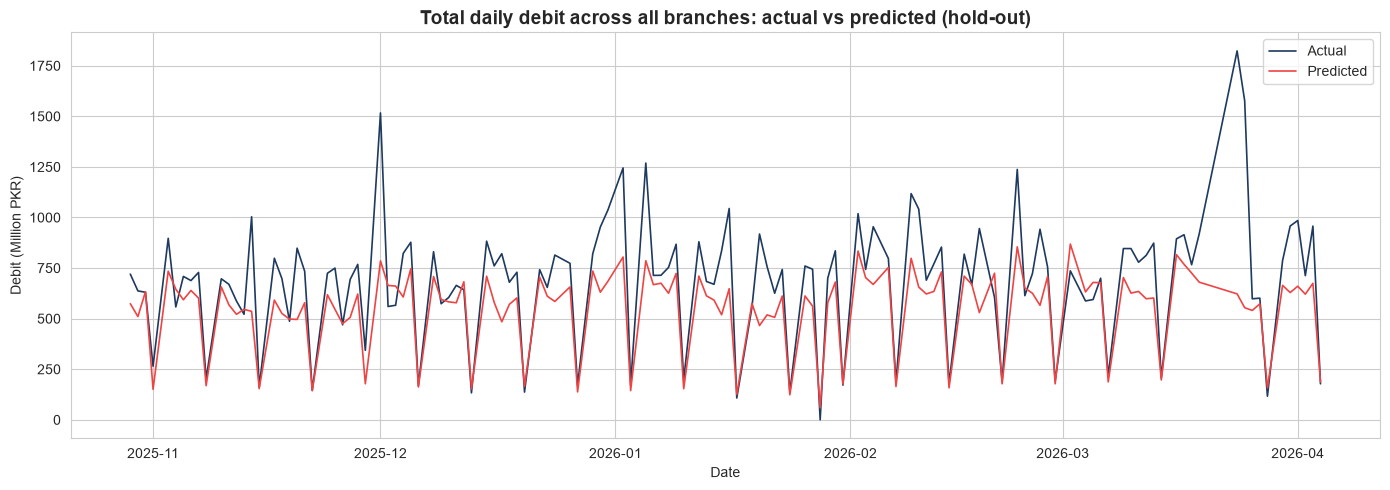

In [24]:
test_dates = test_df['start_date'].values

# summed over all branches per day; per-row lines would overlap across the 15 branches
daily_eval = (pd.DataFrame({'date': test_dates, 'actual': y_test_raw, 'pred': y_pred_ens})
              .groupby('date').sum() / 1e6)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_eval.index, daily_eval['actual'], label='Actual', linewidth=1.2, color='#1e3a5f')
ax.plot(daily_eval.index, daily_eval['pred'], label='Predicted', linewidth=1.2, color='#ef4444')
ax.set_title('Total daily debit across all branches: actual vs predicted (hold-out)', fontsize=14, weight='bold')
ax.set_ylabel('Debit (Million PKR)')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

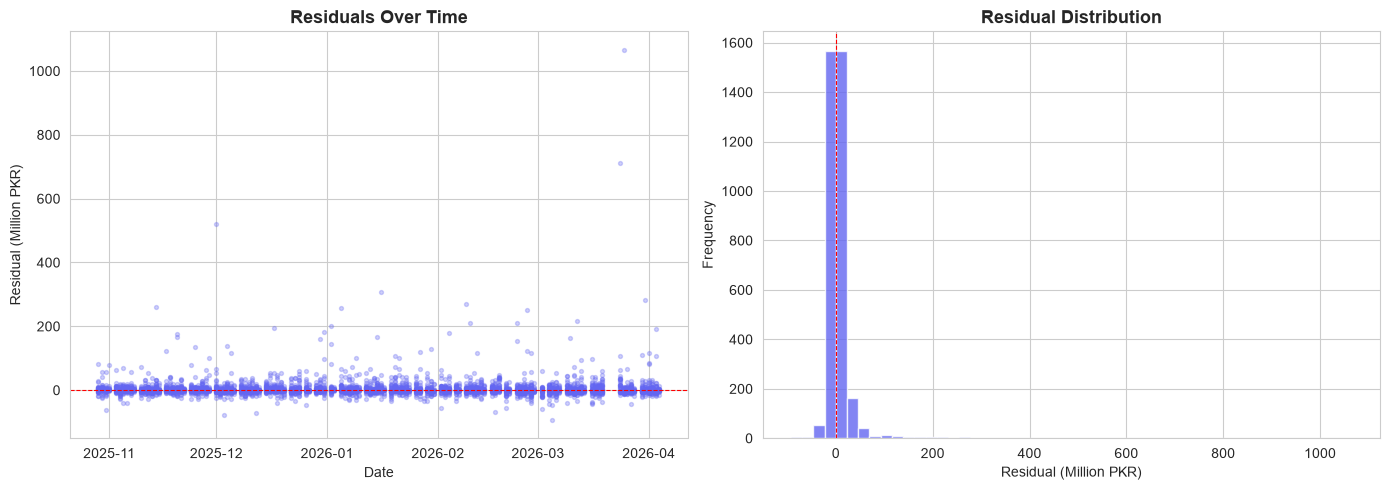

In [25]:
residuals = (y_test_raw - y_pred_ens) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# residuals over time
axes[0].scatter(test_dates, residuals, alpha=0.3, s=8, color='#6366f1')
axes[0].axhline(0, color='red', linestyle='--', linewidth=0.8)
axes[0].set_title('Residuals Over Time', fontsize=13, weight='bold')
axes[0].set_ylabel('Residual (Million PKR)')
axes[0].set_xlabel('Date')

# residual distribution
axes[1].hist(residuals, bins=50, color='#6366f1', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', linewidth=0.8)
axes[1].set_title('Residual Distribution', fontsize=13, weight='bold')
axes[1].set_xlabel('Residual (Million PKR)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### MAPE vs WMAPE

The MAPE values in the comparison are very high (143% to 700% on the hold-out, and 223% averaged over the ensemble's CV folds) even for models that are clearly useful. This section explains why we report WMAPE as the main percentage metric instead.

MAPE averages the percentage error of each row:

$$\text{MAPE} = \frac{100}{n} \sum_{i=1}^{n} \frac{|\text{actual}_i - \text{predicted}_i|}{\text{actual}_i}$$

When the actual value is close to zero, a small absolute error becomes a huge percentage:

| Actual (PKR) | Predicted (PKR) | Absolute error | Row's MAPE |
|---|---|---|---|
| 5,000,000 | 4,000,000 | 1,000,000 | 20% |
| 50,000 | 1,000,000 | 950,000 | 1,900% |
| 10,000 | 1,000,000 | 990,000 | 9,900% |

Some branches have quiet half-days with almost no withdrawals, for example a Friday afternoon at a small branch or the days around a public holiday. That is normal for cash data rather than a data quality problem, but a handful of such rows can dominate a branch's MAPE.

Per-branch figures from the cross-validation in Section 7.0 (5 folds, all 15 branches, 6,905 scored rows, uncapped actuals):

| Branch | Half-days below 100K PKR | MAPE | Rank by MAPE (1 = best) | WMAPE | Rank by WMAPE |
|---|---|---|---|---|---|
| 659 | 4.55% | 752% | 15 | 33.1% | 4 |
| 1200 | 0.70% | 597% | 14 | 38.5% | 7 |
| 394 | 0.88% | 349% | 13 | 28.4% | 1 |
| 104 | 0.00% | 115% | 7 | 50.2% | 15 |
| 202 | 0.70% | 113% | 6 | 32.7% | 3 |

Across all 15 branches the two rankings are unrelated (rank correlation ρ = -0.06). The MAPE ranking follows the share of near-zero half-days (ρ = +0.80); the WMAPE ranking does not (ρ = -0.14). In other words, MAPE mostly measures how many quiet half-days a branch has.

Two examples:

- **Branch 659** has the worst MAPE of all 15 branches (752%) because 4.55% of its half-days are near zero. Its WMAPE of 33.1% is the 4th best and its R² is 0.69.
- **Branch 104** has no near-zero half-days, so its MAPE (115%) looks average (7th of 15). It is actually the weakest branch: WMAPE 50.2%, R² 0.36, and 24% of the total forecast error. MAPE hides the branch that most needs attention.

**Branch 202**, raised in the review, has R² 0.660 and WMAPE 32.7% (both 3rd of 15) and an MAE of 6.98M PKR. A MAPE of 113% looks alarming on its own, but it comes from the 0.70% of its half-days with near-zero demand, not from poor forecasts.

WMAPE divides the total absolute error by the total actual demand:

$$\text{WMAPE} = 100 \times \frac{\sum_{i} |\text{actual}_i - \text{predicted}_i|}{\sum_{i} |\text{actual}_i|}$$

Near-zero rows add almost nothing to either sum, so they cannot dominate the result, and the number reads naturally as "the forecast was off by X% of the cash that actually moved". We use WMAPE as the headline percentage metric and report MAPE only for completeness.

### Stationarity and differencing

An earlier version of the model had a MAPE of 132.7%, and one suggested cause was non-stationary data. We check this with the Augmented Dickey-Fuller (ADF) test on `Half_Day_Total_Debit`: over all branches, per branch, and after the log1p transform. A p-value below 0.05 means the series is stationary. We also test whether predicting the change from the previous half-day, instead of the level, helps.

> **Supervisor note:** Since explicitly differencing the data caused R² to drop from 0.68 to 0.38 in earlier tests, this indicates that the lag features are already successfully capturing the non-stationary information. Thus, we do not need to use explicit differencing for the final models.

All branches:
  Overall (Raw)                  | ADF=-131.2325 | p=0.000000 | stationary
  Overall (log1p)                | ADF=-36.3404 | p=0.000000 | stationary



Per branch:
    Branch |  p-value (raw) |  p-value (log1p) |    Verdict (raw) |    Verdict (log1p)
------------------------------------------------------------------------------------------
       104 |       0.000000 |         0.000009 |       stationary |         stationary
       202 |       0.000001 |         0.000000 |       stationary |         stationary
       234 |       0.000000 |         0.000000 |       stationary |         stationary
       287 |       0.000082 |         0.000044 |       stationary |         stationary
       372 |       0.000000 |         0.000000 |       stationary |         stationary
       394 |       0.000000 |         0.000000 |       stationary |         stationary
       511 |       0.000000 |         0.000000 |       stationary |         stationary
       593 |       0.000000 |         0.000000 |       stationary |         stationary
       659 |       0.000000 |         0.000000 |       stationary |         stationary
      1046 |       0.00000

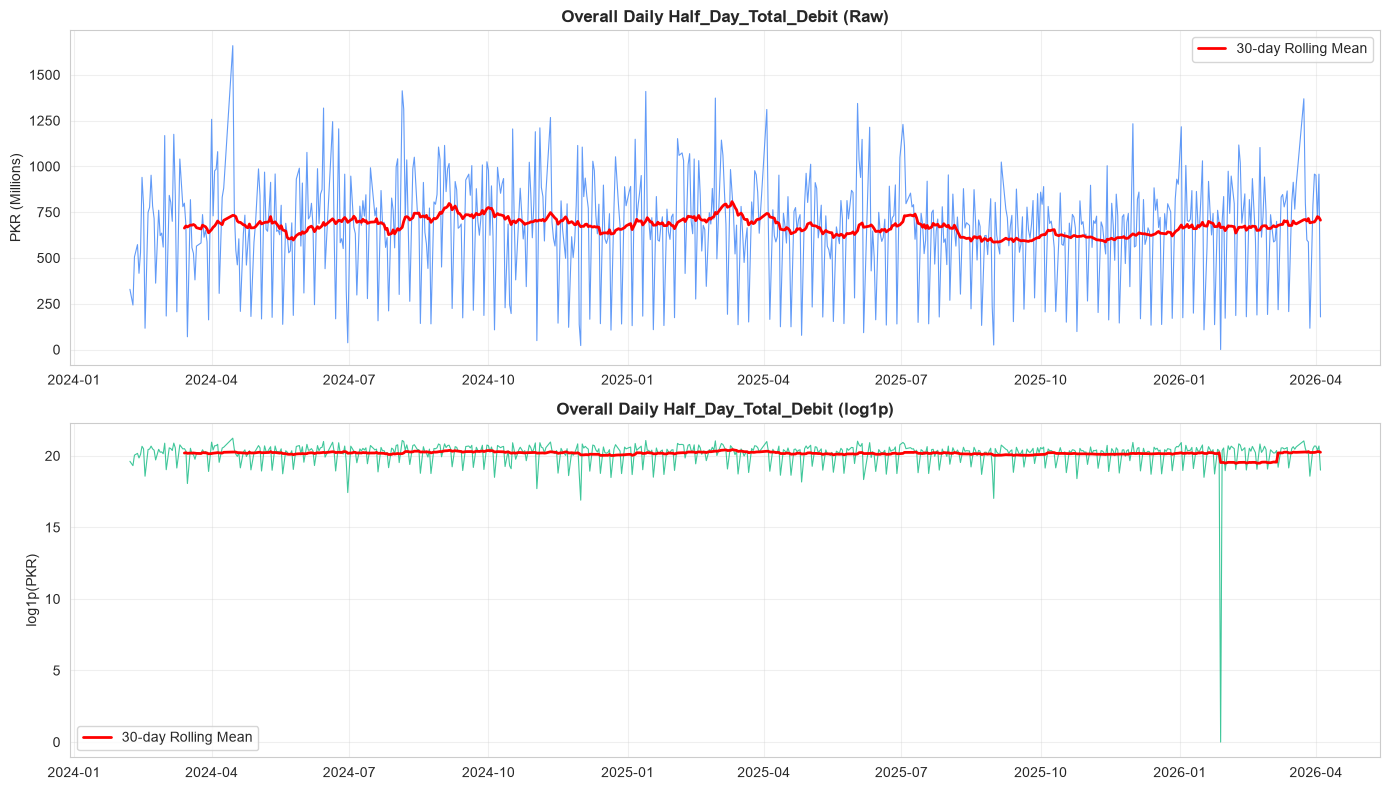

In [26]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label=''):
    series_clean = series.dropna()
    if len(series_clean) < 20:
        return {'label': label, 'adf_stat': np.nan, 'p_value': np.nan, 'verdict': 'too few rows'}
    result = adfuller(series_clean, autolag='AIC')
    p = result[1]
    return {'label': label, 'adf_stat': round(result[0], 4), 'p_value': round(p, 6),
            'verdict': 'stationary' if p < 0.05 else 'non-stationary'}

TARGET = 'Half_Day_Total_Debit'

# all branches together, in date order
overall_raw = run_adf(half_daily.sort_values('start_date')[TARGET], 'Overall (Raw)')
overall_log = run_adf(np.log1p(half_daily.sort_values('start_date')[TARGET].clip(lower=0)), 'Overall (log1p)')

print('All branches:')
print(f"  {overall_raw['label']:30s} | ADF={overall_raw['adf_stat']:8.4f} | p={overall_raw['p_value']:.6f} | {overall_raw['verdict']}")
print(f"  {overall_log['label']:30s} | ADF={overall_log['adf_stat']:8.4f} | p={overall_log['p_value']:.6f} | {overall_log['verdict']}")

# per branch
adf_results = []
for br in sorted(half_daily['tran_br_code'].unique()):
    br_df = half_daily[half_daily['tran_br_code'] == br].sort_values(['start_date', 'AM_PM_Encoded'])
    raw_res = run_adf(br_df[TARGET], f'Branch {br} (Raw)')
    log_res = run_adf(np.log1p(br_df[TARGET].clip(lower=0)), f'Branch {br} (log1p)')
    adf_results.append({'Branch': br, 'p_raw': raw_res['p_value'], 'p_log': log_res['p_value'],
                        'verdict_raw': raw_res['verdict'], 'verdict_log': log_res['verdict']})

adf_df = pd.DataFrame(adf_results)
print('\nPer branch:')
print(f"{'Branch':>10} | {'p-value (raw)':>14} | {'p-value (log1p)':>16} | {'Verdict (raw)':>16} | {'Verdict (log1p)':>18}")
print('-' * 90)
for _, r in adf_df.iterrows():
    print(f"{str(r['Branch']):>10} | {r['p_raw']:>14.6f} | {r['p_log']:>16.6f} | {r['verdict_raw']:>16} | {r['verdict_log']:>18}")

n_stat_raw = (adf_df['verdict_raw'] == 'stationary').sum()
n_stat_log = (adf_df['verdict_log'] == 'stationary').sum()
print(f'\nStationary branches: {n_stat_raw}/15 raw, {n_stat_log}/15 after log1p')

# daily totals with a 30-day rolling mean
daily_overall = half_daily.groupby('start_date')[TARGET].sum().sort_index()
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
axes[0].plot(daily_overall.index, daily_overall.values / 1e6, color='#3B82F6', lw=0.8, alpha=0.8)
if len(daily_overall) > 30:
    axes[0].plot(daily_overall.index, (daily_overall.rolling(30).mean() / 1e6).values, color='red', lw=2, label='30-day Rolling Mean')
    axes[0].legend()
axes[0].set_title('Overall Daily Half_Day_Total_Debit (Raw)', fontweight='bold')
axes[0].set_ylabel('PKR (Millions)')
axes[0].grid(True, alpha=0.3)

daily_log = np.log1p(daily_overall.clip(lower=0))
axes[1].plot(daily_log.index, daily_log.values, color='#10B981', lw=0.8, alpha=0.8)
if len(daily_log) > 30:
    axes[1].plot(daily_log.index, daily_log.rolling(30).mean().values, color='red', lw=2, label='30-day Rolling Mean')
    axes[1].legend()
axes[1].set_title('Overall Daily Half_Day_Total_Debit (log1p)', fontweight='bold')
axes[1].set_ylabel('log1p(PKR)')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# The full experiment (Optuna retraining on the per-branch differenced target) is
# experiments/differencing_experiment.py. It was run before the evaluation fix in Section 7.0,
# so both columns below come from the earlier setup. Its results are copied into this cell.

# per-branch differenced target
half_daily_sorted = half_daily.sort_values(['tran_br_code', 'start_date', 'AM_PM_Encoded']).reset_index(drop=True)
half_daily_sorted['diff_target'] = half_daily_sorted.groupby('tran_br_code')[TARGET].diff(1)
half_daily_sorted['prev_actual'] = half_daily_sorted.groupby('tran_br_code')[TARGET].shift(1)
df_diff = half_daily_sorted.dropna(subset=['diff_target']).copy()

# check that the differenced series are stationary
diff_stat = 0
for br in sorted(df_diff['tran_br_code'].unique()):
    br_s = df_diff[df_diff['tran_br_code'] == br]['diff_target'].dropna()
    if len(br_s) >= 20:
        p = adfuller(br_s, autolag='AIC')[1]
        if p < 0.05: diff_stat += 1
print(f'After differencing: {diff_stat}/15 branches stationary')

decision = {
    "adopted": False,
    "production_mae": 9360000.0,
    "production_r2": 0.5687,
    "production_mape": 132.7,
    "diff_mae": 14882723.495243903,
    "diff_r2": 0.3749700341756034,
    "diff_mape": 197.68256691863832,
    "diff_rmse": 36942638.388570525,
    "mae_improvement_pct": -59.0034561457682,
    "r2_improvement_pct": -44.73544079946892,
    "mape_improvement_pct": -48.969530458657374
}

print(f"\n{'':>6} | {'Levels (used)':>14} | {'Differenced':>12}")
print(f"{'R2':>6} | {decision['production_r2']:>14.4f} | {decision['diff_r2']:>12.4f}")
print(f"{'MAE':>6} | {decision['production_mae']/1e6:>13.2f}M | {decision['diff_mae']/1e6:>11.2f}M")
print(f"{'MAPE':>6} | {decision['production_mape']:>13.1f}% | {decision['diff_mape']:>11.1f}%")
print("\nDifferencing adopted" if decision['adopted'] else "\nDifferencing not adopted: all three metrics got worse")

After differencing: 15/15 branches stationary

       |  Levels (used) |  Differenced
    R2 |         0.5687 |       0.3750
   MAE |          9.36M |       14.88M
  MAPE |         132.7% |       197.7%

Differencing not adopted: all three metrics got worse


All 15 branches are stationary at p < 0.05, both raw and after log1p, so non-stationarity does not explain the high MAPE; the near-zero half-days described above do. Differencing made R², MAE and MAPE worse, in line with the note above: the lag features already carry the level information, so the final model predicts levels directly.

---
# 7. Per-branch evaluation

Overall metrics hide large differences between branches. This section looks at how the ensemble does for each branch, first with cross-validation (7.0) and then on the hold-out (7.1 to 7.3).

## 7.0 Is the cross-validation variance concentrated in a few branches?

The review asked:

> "For R² = 0.5687 ± 0.0581 and WMAPE = 39.5% ± 3.3%, the variation between folds is a little high. Please check the performance for each branch, especially branches 202 and 1739. We need to see whether a few branches are causing the higher variation or if the issue is spread across all branches. This will help us decide whether we need branch-level tuning or more data for the weaker branches."

The original cross-validation could not answer this, because three branches (including 202) never appeared in a validation fold. Step 1 shows why. The notebook now uses date-based folds (Section 5), and `src/v3_pipeline.py` was re-run with them to produce the hyperparameters used here. Features and model are the same as before.

Steps:
1. Why three branches were never validated
2. Per-branch results with the corrected folds
3. Is the fold-to-fold spread caused by a few branches?
4. Charts
5. Per-branch models vs more data
6. Branches 202 and 1739, the hold-out, and per-branch tiers
7. The numbers behind this summary

**Summary**

| Question | Answer |
|---|---|
| Is the fold-to-fold variance caused by a few branches? | It depends on the metric. For R², mostly one branch: removing branch 104 cuts the R² standard deviation across folds by 52%. Branch 104 is by far the largest branch and R² is computed on the pooled data, so its swings dominate. For WMAPE, no: removing branch 104 cuts the spread by 33%, and removing the five worst branches still leaves 72% of it. |
| Is it a time-period effect instead? | Only a small one. Which fold (period) a result comes from explains 5.7% of the variation in branch-by-fold WMAPE. In the weakest fold (fold 3), 11 of 15 branches were worse than their own average. |
| What drives the differences? | Mainly the branch itself: 66% of the variation in branch-by-fold WMAPE is explained by which branch it is. Branches with more volatile demand have higher WMAPE (correlation +0.71). |
| Branch 202 | One of the strongest: R² 0.66 and WMAPE 32.7%, both 3rd of 15. Its high MAPE comes from near-zero half-days. |
| Branch 1739 | Weak: R² 0.36, WMAPE 48.0%, 14th of 15. The concern was justified. |
| Branch 104 | Not flagged in the review, but the weakest branch: WMAPE 50.2%, and 24% of the total forecast error on 19% of total demand. |
| Branch-level tuning or more data? | Neither helped in our tests. A separate model per branch (same features and hyperparameters, trained only on that branch) was worse for 15 of 15 branches, by 2.9 WMAPE points on average. We did not run a separate hyperparameter search per branch. History length (1,042 to 1,268 rows per branch) shows no clear link with accuracy (r = +0.19). |

In [28]:
# Step 1: why three branches were never validated under the original cross-validation
import numpy as np
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit

_hd = half_daily
print(f"Rows: {len(_hd):,}   Branches: {_hd['tran_br_code'].nunique()}   "
      f"Dates: {_hd['start_date'].min().date()} -> {_hd['start_date'].max().date()}")

# row order that the CV sees
print("\n1. Is the dataframe ordered by time?")
print(f"   start_date monotonically increasing across rows : {_hd['start_date'].is_monotonic_increasing}")
print("\n   Row-index block occupied by each branch:")
_blocks = _hd.reset_index().groupby('tran_br_code', observed=True)['index'].agg(['min', 'max', 'count'])
print(_blocks.to_string())
print("\n   -> The frame is sorted by ['tran_br_code', 'start_date', ...] (Section 5), so consecutive")
print("      row indices are consecutive branches, not consecutive dates.")

# what TimeSeriesSplit produces on this order
_cut_idx = int(len(_hd) * 0.8)
_cut_date = _hd.iloc[_cut_idx]['start_date']
_train = _hd[_hd['start_date'] < _cut_date]

print("\n2. What the 3-fold TimeSeriesSplit produces:")
_tscv = TimeSeriesSplit(n_splits=3)
_coverage = {int(b): 0 for b in _hd['tran_br_code'].cat.categories}
for _f, (_tr, _va) in enumerate(_tscv.split(_train), 1):
    _vd, _td = _train.iloc[_va], _train.iloc[_tr]
    _leak = (_td['start_date'] >= _vd['start_date'].min()).mean() * 100
    print(f"\n   Fold {_f}:  train n={len(_tr):>6,}   val n={len(_va):>6,}")
    print(f"      train dates : {_td['start_date'].min().date()} -> {_td['start_date'].max().date()}")
    print(f"      val   dates : {_vd['start_date'].min().date()} -> {_vd['start_date'].max().date()}")
    print(f"      branches in validation : {sorted(int(b) for b in _vd['tran_br_code'].unique())}")
    print(f"      share of training rows dated on or after the start of the validation window : {_leak:.1f}%")
    for _b in _vd['tran_br_code'].unique():
        _coverage[int(_b)] += 1

print("\n3. Resulting branch coverage across the three validation folds:")
for _b, _n in sorted(_coverage.items()):
    _flag = '  <-- never validated' if _n == 0 else ''
    print(f"      Branch {_b:>5}: {_n}/3 folds{_flag}")

_never = [b for b, n in _coverage.items() if n == 0]
print(f"\n   Branches never validated: {_never}")

Rows: 17,117   Branches: 15   Dates: 2024-02-07 -> 2026-04-04

1. Is the dataframe ordered by time?
   start_date monotonically increasing across rows : False

   Row-index block occupied by each branch:
                min    max  count
tran_br_code                     
104               0   1267   1268
202            1268   2375   1108
234            2376   3421   1046
287            3422   4555   1134
372            4556   5637   1082
394            5638   6777   1140
511            6778   7904   1127
593            7905   9055   1151
659            9056  10155   1100
1046          10156  11416   1261
1092          11417  12651   1235
1200          12652  13702   1051
1297          13703  14876   1174
1376          14877  16074   1198
1739          16075  17116   1042

   -> The frame is sorted by ['tran_br_code', 'start_date', ...] (Section 5), so consecutive
      row indices are consecutive branches, not consecutive dates.

2. What the 3-fold TimeSeriesSplit produces:

   Fold 1:

### Step 1 result: the original folds were blocks of branches, not blocks of time

`TimeSeriesSplit` splits a dataframe by row position and assumes the rows are in time order. Our frame is sorted by `['tran_br_code', 'start_date', 'AM_PM_Encoded']`, so rows 0 to 1,267 are branch 104, rows 1,268 to 2,375 are branch 202, and so on. Splitting it by position gave blocks of branches.

This had three effects, all visible above:

1. Each validation fold contained only 4 or 5 branches, and branches 104, 202 and 234 were always in the training part. That is why the earlier per-branch table was mostly empty and branch 202 could not be reported.
2. Training and validation covered the same dates (Feb 2024 to Mar 2026). Almost every training row was dated on or after the start of its validation window, so the model was scored on the same period it was trained on.
3. The reported ± therefore measured how the 4 or 5 branches in one fold differed from those in the next, not how stable the forecast is over time.

The same issue shrank the hold-out: `cutoff_idx = int(len(df) * 0.8)` picked a row inside branch 1200's rows, and that row's date became the cutoff. The hold-out was only the last few days of data, 164 rows (1.0%), instead of 20%.

Both are fixed. The split and the folds are now built from the list of unique dates (Section 5), so the hold-out has 3,457 rows (20.2%, 29 Oct 2025 to 4 Apr 2026) and all 15 branches appear in all 5 validation folds. Section 6.4, this section and `src/v3_pipeline.py` use the same helper functions. Step 6 compares the old and new hold-out.

In [29]:
# Step 2: per-branch results with the corrected folds
# Uses CV_FOLDS (Section 5) and cv_params / build_ensemble (Section 6.4), so the numbers match 6.4.
# Models are fitted on the capped target and scored against the uncapped one.
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

CV_TARGET   = 'Half_Day_Total_Debit'
CV_EVAL_COL = 'Half_Day_Total_Debit_RAW' if 'Half_Day_Total_Debit_RAW' in half_daily.columns else CV_TARGET
_BP = cv_params[CV_TARGET]['best_params']
_W  = cv_params[CV_TARGET]['w_xgb']


def cv_wmape(a, p):
    """Weighted MAPE: total absolute error / total absolute actual."""
    a, p = np.asarray(a, float), np.asarray(p, float)
    d = np.abs(a).sum()
    return float(np.abs(a - p).sum() / d * 100) if d > 0 else np.nan


def cv_mape(a, p):
    a, p = np.asarray(a, float), np.asarray(p, float)
    m = a != 0
    return float(np.mean(np.abs((a[m] - p[m]) / a[m])) * 100) if m.sum() else np.nan


def cv_fit_predict(tr, va, cols=None):
    """Fit the production ensemble on `tr`, predict `va`."""
    cols = feature_cols if cols is None else cols
    y = tr[CV_TARGET]                                     # winsorized series for fitting
    y = np.log1p(y.clip(upper=y.quantile(0.99)).clip(lower=0))
    mx, ml = build_ensemble(_BP)
    mx.fit(tr[cols], y)
    ml.fit(tr[cols], y)
    return np.expm1(_W * mx.predict(va[cols]) + (1 - _W) * ml.predict(va[cols]))


print(f"Scored against {CV_EVAL_COL} | {len(CV_FOLDS)} folds | blend: XGB {_W:.4f} / LGB {1 - _W:.4f}\n")

_rows, _agg = [], []
for _k, (_tr_i, _va_i) in enumerate(CV_FOLDS, 1):
    _tr, _va = train_df.iloc[_tr_i], train_df.iloc[_va_i]
    _p = cv_fit_predict(_tr, _va)
    _y = _va[CV_EVAL_COL].values
    _agg.append({'Fold': _k,
                 'Val window': f"{_va['start_date'].min().date()} -> {_va['start_date'].max().date()}",
                 'n_train': len(_tr), 'n_val': len(_va),
                 'Branches': int(_va['tran_br_code'].nunique()),
                 'R2': r2_score(_y, _p), 'MAE_M': mean_absolute_error(_y, _p) / 1e6,
                 'WMAPE_%': cv_wmape(_y, _p), 'MAPE_%': cv_mape(_y, _p)})
    _rows.append(pd.DataFrame({'fold': _k, 'branch': _va['tran_br_code'].astype(int).values,
                               'date': _va['start_date'].values, 'actual': _y, 'pred': _p}))
    print(f"  Fold {_k}: {_agg[-1]['Val window']} | train {len(_tr):>6,} | val {len(_va):>5,} | "
          f"branches {_agg[-1]['Branches']:>2} | R2 {_agg[-1]['R2']:.4f} | WMAPE {_agg[-1]['WMAPE_%']:.2f}%")

CV_PREDS    = pd.concat(_rows, ignore_index=True)
CV_FOLD_TBL = pd.DataFrame(_agg)

print("\nFold summary")
print(CV_FOLD_TBL.round(4).to_string(index=False))

CV_R2_MEAN, CV_R2_STD = CV_FOLD_TBL['R2'].mean(), CV_FOLD_TBL['R2'].std(ddof=1)
CV_WM_MEAN, CV_WM_STD = CV_FOLD_TBL['WMAPE_%'].mean(), CV_FOLD_TBL['WMAPE_%'].std(ddof=1)
print(f"\n  Overall: R2 = {CV_R2_MEAN:.4f} +/- {CV_R2_STD:.4f}   "
      f"WMAPE = {CV_WM_MEAN:.2f}% +/- {CV_WM_STD:.2f}%")
print(f"  All {int(CV_FOLD_TBL['Branches'].min())} branches appear in all {len(CV_FOLDS)} validation folds.")

# metrics per branch and fold, then per branch
_bf = []
for (_b, _k), _g in CV_PREDS.groupby(['branch', 'fold']):
    _bf.append({'branch': _b, 'fold': _k, 'n': len(_g),
                'r2': r2_score(_g['actual'], _g['pred']),
                'mae_M': mean_absolute_error(_g['actual'], _g['pred']) / 1e6,
                'wmape': cv_wmape(_g['actual'].values, _g['pred'].values),
                'mape': cv_mape(_g['actual'].values, _g['pred'].values),
                'abs_err': float(np.abs(_g['actual'] - _g['pred']).sum()),
                'abs_act': float(np.abs(_g['actual']).sum())})
CV_BRANCH_FOLD = pd.DataFrame(_bf)

CV_BRANCH = CV_BRANCH_FOLD.groupby('branch').agg(
    Folds=('fold', 'nunique'), Rows=('n', 'sum'),
    R2_mean=('r2', 'mean'),       R2_std=('r2', lambda s: s.std(ddof=1)),
    WMAPE_mean=('wmape', 'mean'), WMAPE_std=('wmape', lambda s: s.std(ddof=1)),
    MAE_mean=('mae_M', 'mean'),   MAE_std=('mae_M', lambda s: s.std(ddof=1)),
    MAPE_mean=('mape', 'mean')).reset_index()

_tot_e, _tot_a = CV_BRANCH_FOLD['abs_err'].sum(), CV_BRANCH_FOLD['abs_act'].sum()
_sh = CV_BRANCH_FOLD.groupby('branch')[['abs_err', 'abs_act']].sum()
CV_BRANCH = CV_BRANCH.merge(pd.DataFrame({
    'branch': _sh.index.to_numpy(),
    'ErrShare_%': (_sh['abs_err'] / _tot_e * 100).to_numpy(),
    'DemandShare_%': (_sh['abs_act'] / _tot_a * 100).to_numpy()}), on='branch')
CV_BRANCH['Err_vs_Demand'] = CV_BRANCH['ErrShare_%'] / CV_BRANCH['DemandShare_%']

print("\nPer-branch results, worst WMAPE first")
print("  R2_std, WMAPE_std: variation of the branch's own score across the 5 folds")
print("  Err_vs_Demand: share of total error / share of total demand (above 1 = more error than its size)\n")
print(CV_BRANCH.sort_values('WMAPE_mean', ascending=False).round(3).to_string(index=False))


def cv_tier(r):
    if r['R2_mean'] >= 0.60 and r['WMAPE_mean'] <= 37:
        return 'Production ready'
    if r['R2_mean'] >= 0.50 and r['WMAPE_mean'] <= 45:
        return 'Acceptable (monitor)'
    return 'Needs attention'


CV_BRANCH['Tier'] = CV_BRANCH.apply(cv_tier, axis=1)
print("\nTier counts: " + ", ".join(f"{k} = {v}" for k, v in CV_BRANCH['Tier'].value_counts().items()))

Scored against Half_Day_Total_Debit_RAW | 5 folds | blend: XGB 0.8000 / LGB 0.2000



  Fold 1: 2024-12-19 -> 2025-02-19 | train  6,755 | val 1,335 | branches 15 | R2 0.6523 | WMAPE 36.43%


  Fold 2: 2025-02-20 -> 2025-04-24 | train  8,090 | val 1,372 | branches 15 | R2 0.5965 | WMAPE 38.00%


  Fold 3: 2025-04-25 -> 2025-06-27 | train  9,462 | val 1,365 | branches 15 | R2 0.5327 | WMAPE 41.50%


  Fold 4: 2025-06-28 -> 2025-08-29 | train 10,827 | val 1,419 | branches 15 | R2 0.4952 | WMAPE 42.34%


  Fold 5: 2025-08-30 -> 2025-10-28 | train 12,246 | val 1,414 | branches 15 | R2 0.6299 | WMAPE 39.40%

Fold summary
 Fold               Val window  n_train  n_val  Branches     R2   MAE_M  WMAPE_%   MAPE_%
    1 2024-12-19 -> 2025-02-19     6755   1335        15 0.6523 10.0321  36.4322  79.7040
    2 2025-02-20 -> 2025-04-24     8090   1372        15 0.5965  9.7642  37.9954 151.3306
    3 2025-04-25 -> 2025-06-27     9462   1365        15 0.5327 10.4668  41.4968 314.4286
    4 2025-06-28 -> 2025-08-29    10827   1419        15 0.4952  9.8800  42.3446 222.7712
    5 2025-08-30 -> 2025-10-28    12246   1414        15 0.6299  8.6803  39.4000 348.6816

  Overall: R2 = 0.5813 +/- 0.0660   WMAPE = 39.53% +/- 2.44%
  All 15 branches appear in all 5 validation folds.



Per-branch results, worst WMAPE first
  R2_std, WMAPE_std: variation of the branch's own score across the 5 folds
  Err_vs_Demand: share of total error / share of total demand (above 1 = more error than its size)

 branch  Folds  Rows  R2_mean  R2_std  WMAPE_mean  WMAPE_std  MAE_mean  MAE_std  MAPE_mean  ErrShare_%  DemandShare_%  Err_vs_Demand
    104      5   506    0.363   0.147      50.175      7.337    31.762    5.780    115.353      23.870         18.826          1.268
   1739      5   424    0.357   0.090      48.002      3.675     5.818    1.417    191.620       3.657          2.981          1.227
    593      5   460    0.493   0.184      41.397      6.387     5.852    1.275    109.567       3.992          3.787          1.054
   1046      5   506    0.563   0.036      40.527      2.749    19.760    6.532     89.364      14.860         14.578          1.019
    287      5   468    0.584   0.146      40.501      4.133     4.485    0.907    248.106       3.076          2.997   

In [30]:
# Step 3: is the fold-to-fold spread caused by a few branches?
# All three tests reuse the fold predictions from Step 2, without refitting.

import numpy as np, pandas as pd
from sklearn.metrics import r2_score


def _fold_stats(sub):
    """Mean and std across folds of R2 and WMAPE, for a subset of branches."""
    out = []
    for f, g in sub.groupby('fold'):
        out.append({'fold': f, 'R2': r2_score(g['actual'], g['pred']),
                    'WMAPE': cv_wmape(g['actual'].values, g['pred'].values)})
    d = pd.DataFrame(out)
    return d['R2'].mean(), d['R2'].std(ddof=1), d['WMAPE'].mean(), d['WMAPE'].std(ddof=1)


_BR2M, _BR2S, _BWMM, _BWMS = _fold_stats(CV_PREDS)

# Test 1: leave one branch out
print("Test 1: leave one branch out and recompute the spread across folds")
print(f"All 15 branches: R2 std = {_BR2S:.4f}, WMAPE std = {_BWMS:.3f} pp\n")
_l = []
for _b in sorted(CV_PREDS['branch'].unique()):
    _m, _s, _wm, _ws = _fold_stats(CV_PREDS[CV_PREDS['branch'] != _b])
    _l.append({'Branch removed': _b, 'R2_std': _s, 'R2_std change %': (_s - _BR2S) / _BR2S * 100,
               'WMAPE_std': _ws, 'WMAPE_std change %': (_ws - _BWMS) / _BWMS * 100})
CV_LOBO = pd.DataFrame(_l).sort_values('R2_std change %')
print(CV_LOBO.round(3).to_string(index=False))
_best, _others = CV_LOBO.iloc[0], CV_LOBO.iloc[1:]
_next = max(0.0, -min(_others['R2_std change %'].min(), _others['WMAPE_std change %'].min()))
print(f"\nRemoving branch {int(_best['Branch removed'])} cuts the R2 std by {-_best['R2_std change %']:.0f}% "
      f"and the WMAPE std by {-_best['WMAPE_std change %']:.0f}%.")
print(f"No other single branch reduces either by more than {_next:.0f}%.")

# Test 2: remove the worst branches one after another
print("\nTest 2: remove the worst branches (by mean WMAPE) one after another")
_worst = CV_BRANCH.sort_values('WMAPE_mean', ascending=False)['branch'].tolist()
print(f"{'Excluded':<42}{'R2 mean':>9}{'R2 std':>9}{'WMAPE mean':>12}{'WMAPE std':>11}")
print(f"{'(none)':<42}{_BR2M:>9.4f}{_BR2S:>9.4f}{_BWMM:>12.2f}{_BWMS:>11.3f}")
_cum = []
for _i in range(1, 6):
    _ex = _worst[:_i]
    _m, _s, _wm, _ws = _fold_stats(CV_PREDS[~CV_PREDS['branch'].isin(_ex)])
    _cum.append({'k': _i, 'R2_std': _s, 'WMAPE_std': _ws})
    print(f"{'worst ' + str(_i) + ': ' + str(_ex):<42}{_m:>9.4f}{_s:>9.4f}{_wm:>12.2f}{_ws:>11.3f}")
_r = _cum[-1]['WMAPE_std'] / _BWMS
CV_CUM_EXCL, CV_CUM5_RATIO = _cum, _r
CV_BASE_R2_STD, CV_BASE_WM_STD = _BR2S, _BWMS
print(f"\nWith the five worst branches removed, {_r * 100:.0f}% of the WMAPE spread and "
      f"{_cum[-1]['R2_std'] / _BR2S * 100:.0f}% of the R2 spread remain.")

# Test 3: split the branch x fold matrix into a branch effect, a fold effect and the rest
print("\nTest 3: how much of the branch x fold variation comes from the branch and how much from the fold")


def _decompose(metric):
    M = CV_BRANCH_FOLD.pivot(index='branch', columns='fold', values=metric)
    g = M.values.mean()
    be = M.mean(axis=1) - g          # branch effect
    fe = M.mean(axis=0) - g          # fold (time period) effect
    rs = M.values - g - be.values[:, None] - fe.values[None, :]
    ssb, ssf, ssr = (be ** 2).sum() * M.shape[1], (fe ** 2).sum() * M.shape[0], (rs ** 2).sum()
    t = ssb + ssf + ssr
    return M, g, be, fe, ssb / t * 100, ssf / t * 100, ssr / t * 100


CV_WM_MATRIX, _g, CV_BRANCH_EFFECT, CV_FOLD_EFFECT, _pb, _pf, _pi = _decompose('wmape')
_, _, _, _, _pb2, _pf2, _pi2 = _decompose('r2')
_ANOVA_WMAPE = (_pb, _pf, _pi)      # (branch %, fold %, interaction %)
_ANOVA_R2    = (_pb2, _pf2, _pi2)

print(f"\nWMAPE: branch {_pb:.1f}%, fold {_pf:.1f}%, branch x fold {_pi:.1f}%  (mean WMAPE {_g:.2f}%)")
print(f"R2   : branch {_pb2:.1f}%, fold {_pf2:.1f}%, branch x fold {_pi2:.1f}%")

print("\nFold effect on WMAPE, and how many branches moved in the same direction:")
for _f in CV_WM_MATRIX.columns:
    _dev = CV_WM_MATRIX[_f] - CV_WM_MATRIX.mean(axis=1)
    _same = int(np.sign(_dev).eq(np.sign(CV_FOLD_EFFECT[_f])).sum())
    print(f"   Fold {_f}: {CV_FOLD_EFFECT[_f]:+6.2f} pp, {_same:>2} of 15 branches")

# does the fold effect follow the demand volatility of the validation window?
_vol = []
for _k, (_tr_i, _va_i) in enumerate(CV_FOLDS, 1):
    _w = train_df.iloc[_va_i][CV_EVAL_COL]          # CV_FOLDS holds positional indices
    _vol.append({'fold': _k, 'CoV': _w.std() / _w.mean()})
CV_VOL = pd.DataFrame(_vol).merge(
    CV_FOLD_TBL[['Fold', 'WMAPE_%', 'R2']].rename(columns={'Fold': 'fold'}), on='fold')
CV_VOL_CORR = float(np.corrcoef(CV_VOL['CoV'], CV_VOL['WMAPE_%'])[0, 1])
print("\nDemand volatility (CoV) of each validation window vs the fold's WMAPE:")
print(CV_VOL.round(4).to_string(index=False))
print(f"\ncorrelation = {CV_VOL_CORR:+.3f} (only 5 folds, so this says little either way)")

Test 1: leave one branch out and recompute the spread across folds
All 15 branches: R2 std = 0.0660, WMAPE std = 2.437 pp

 Branch removed  R2_std  R2_std change %  WMAPE_std  WMAPE_std change %
            104   0.032          -51.647      1.636             -32.864
            593   0.066            0.042      2.446               0.383
           1739   0.066            0.229      2.421              -0.652
            372   0.066            0.698      2.309              -5.254
            394   0.067            0.932      2.593               6.409
           1297   0.067            1.272      2.360              -3.156
            234   0.067            1.815      2.556               4.862
            202   0.067            1.942      2.639               8.277
            659   0.067            2.058      2.387              -2.073
           1376   0.068            3.081      2.643               8.443
            511   0.068            3.812      2.638               8.257
           12

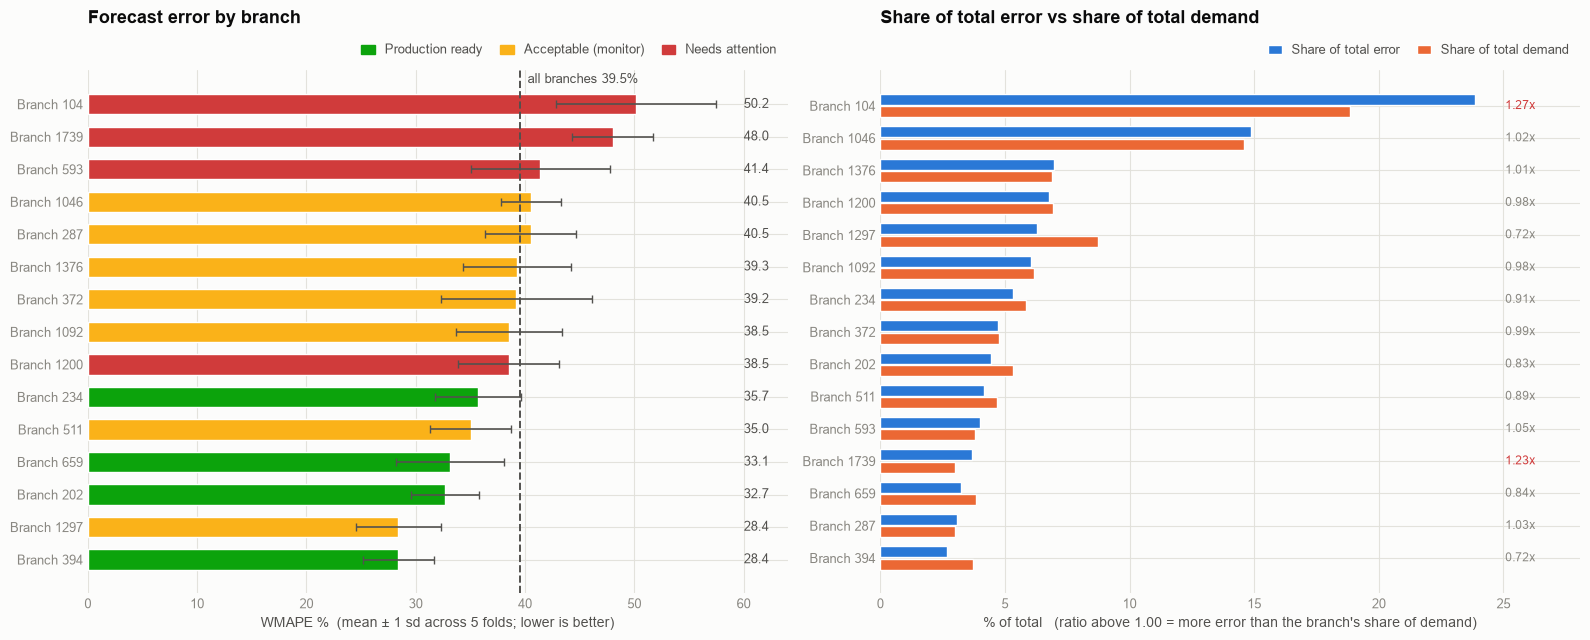

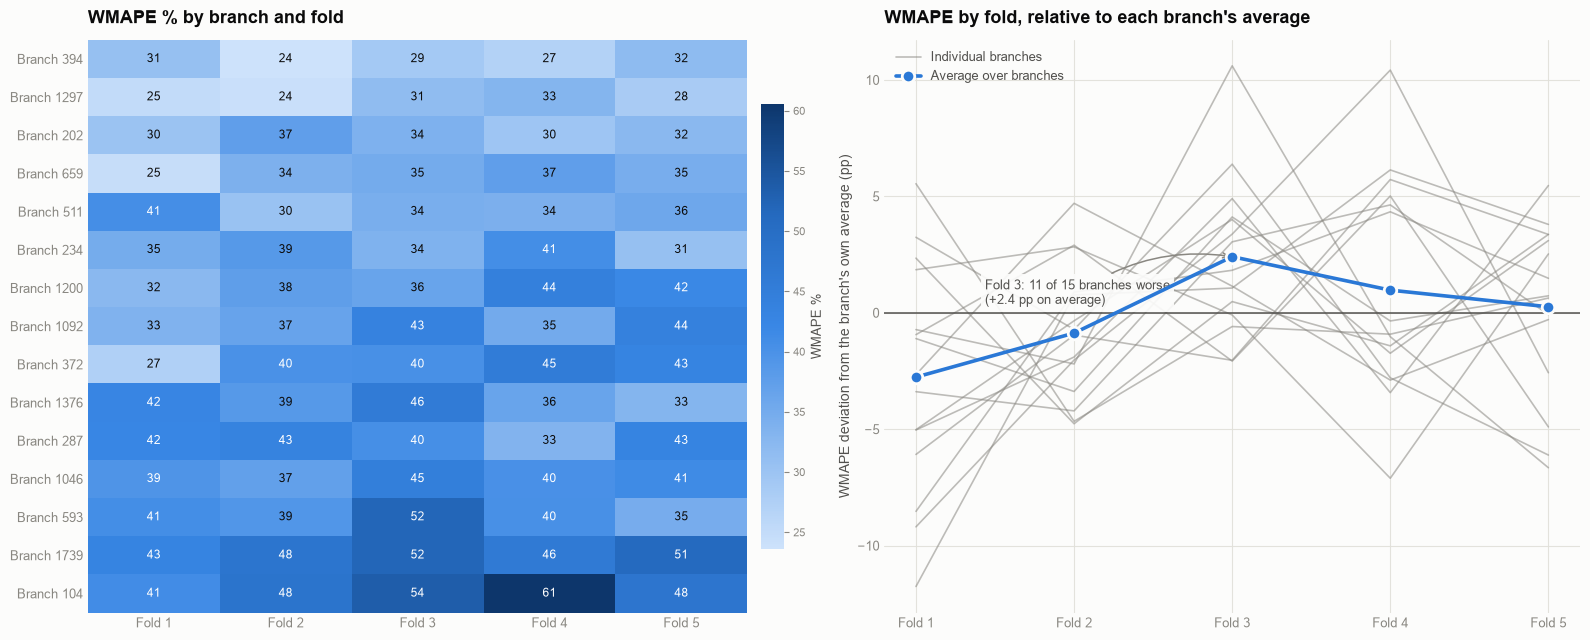

In [31]:
# Step 4: charts
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

INK, INK2, MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#e1e0d9', '#fcfcfb'
GOOD, WARNING, CRITICAL = '#0ca30c', '#fab219', '#d03b3b'
BLUE, ORANGE = '#2a78d6', '#eb6834'
SEQ = mcolors.LinearSegmentedColormap.from_list('seq_blue', ['#cde2fb', '#86b6ef', '#3987e5', '#256abf', '#0d366b'])


def _style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, lw=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)


TIER_COLOR = {'Production ready': GOOD, 'Acceptable (monitor)': WARNING, 'Needs attention': CRITICAL}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5), facecolor=SURFACE)

# Chart 1: per-branch WMAPE, mean +/- 1 sd across the 5 folds
d = CV_BRANCH.sort_values('WMAPE_mean')
y = np.arange(len(d))
ax1.barh(y, d['WMAPE_mean'], xerr=d['WMAPE_std'], height=0.62,
         color=[TIER_COLOR[t] for t in d['Tier']],
         error_kw=dict(ecolor=INK2, lw=1.2, capsize=3), zorder=3)
ax1.axvline(CV_WM_MEAN, color=INK2, ls='--', lw=1.4, zorder=4)
ax1.text(CV_WM_MEAN + 0.7, len(d) - 0.35, f'all branches {CV_WM_MEAN:.1f}%', color=INK2, fontsize=9)
_lx = max(d['WMAPE_mean'] + d['WMAPE_std']) + 2.5       # one label column, clear of every bar
for i, v in enumerate(d['WMAPE_mean']):
    ax1.text(_lx, i, f'{v:.1f}', va='center', fontsize=9, color=INK2, zorder=6)
ax1.set_yticks(y, [f'Branch {b}' for b in d['branch']], fontsize=9)
ax1.set_xlabel('WMAPE %  (mean ± 1 sd across 5 folds; lower is better)', color=INK2, fontsize=10)
ax1.set_title('Forecast error by branch', color=INK, fontsize=13, weight='bold', loc='left', pad=34)
ax1.set_xlim(0, _lx + 4)
_style(ax1)
ax1.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=TIER_COLOR[t]) for t in TIER_COLOR],
           labels=list(TIER_COLOR), frameon=False, fontsize=9, ncol=3, labelcolor=INK2,
           loc='lower right', bbox_to_anchor=(1.0, 1.005), handlelength=1.1, columnspacing=1.4)

# Chart 2: share of portfolio error vs share of portfolio demand
d2 = CV_BRANCH.sort_values('ErrShare_%', ascending=True)
y2 = np.arange(len(d2))
ax2.barh(y2 + 0.19, d2['ErrShare_%'], height=0.34, color=BLUE, label='Share of total error', zorder=3)
ax2.barh(y2 - 0.19, d2['DemandShare_%'], height=0.34, color=ORANGE, label='Share of total demand', zorder=3)
_lx2 = max(d2[['ErrShare_%', 'DemandShare_%']].max()) + 1.2
for i, (e, dm) in enumerate(zip(d2['ErrShare_%'], d2['DemandShare_%'])):
    ax2.text(_lx2, i, f'{e / dm:.2f}x', va='center', fontsize=8.5,
             color=CRITICAL if e / dm > 1.10 else MUTED)
ax2.set_xlim(0, _lx2 + 3)
ax2.set_yticks(y2, [f'Branch {b}' for b in d2['branch']], fontsize=9)
ax2.set_xlabel('% of total   (ratio above 1.00 = more error than the branch\'s share of demand)',
               color=INK2, fontsize=10)
ax2.set_title('Share of total error vs share of total demand', color=INK, fontsize=13, weight='bold',
              loc='left', pad=34)
_style(ax2)
ax2.legend(frameon=False, fontsize=9, ncol=2, labelcolor=INK2,
           loc='lower right', bbox_to_anchor=(1.0, 1.005), handlelength=1.1, columnspacing=1.4)
plt.tight_layout()
plt.show()

# Chart 3 & 4
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 6.5), facecolor=SURFACE)

M = CV_WM_MATRIX.loc[CV_BRANCH.sort_values('WMAPE_mean')['branch'].values]
_vmin, _vmax = np.nanmin(M.values), np.nanmax(M.values)
_norm = plt.Normalize(_vmin, _vmax)
im = ax3.imshow(M.values, cmap=SEQ, aspect='auto', vmin=_vmin, vmax=_vmax)
ax3.set_xticks(range(M.shape[1]), [f'Fold {c}' for c in M.columns], fontsize=9)
ax3.set_yticks(range(M.shape[0]), [f'Branch {b}' for b in M.index], fontsize=9)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M.values[i, j]
        _r, _g_, _b_, _ = SEQ(_norm(v))                       # ink chosen against the actual cell fill
        _lum = 0.2126 * _r + 0.7152 * _g_ + 0.0722 * _b_
        ax3.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=8.5,
                 color='#ffffff' if _lum < 0.55 else INK)
ax3.set_title('WMAPE % by branch and fold', color=INK, fontsize=13, weight='bold', loc='left', pad=12)
ax3.tick_params(colors=MUTED, length=0)
ax3.grid(False)
for s in ax3.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax3, fraction=0.032, pad=0.02)
cb.set_label('WMAPE %', color=INK2, fontsize=9)
cb.ax.tick_params(colors=MUTED, labelsize=8)
cb.outline.set_visible(False)

for b in CV_WM_MATRIX.index:
    ax4.plot(CV_WM_MATRIX.columns, CV_WM_MATRIX.loc[b] - CV_WM_MATRIX.loc[b].mean(),
             color=MUTED, lw=1.2, alpha=0.55, zorder=2,
             label='Individual branches' if b == CV_WM_MATRIX.index[0] else None)
ax4.plot(CV_FOLD_EFFECT.index, CV_FOLD_EFFECT.values, color=BLUE, lw=2.6, marker='o',
         ms=9, zorder=4, label='Average over branches', markeredgecolor=SURFACE, markeredgewidth=2)
ax4.axhline(0, color=INK2, lw=1.1, zorder=3)
ax4.set_xticks(list(CV_WM_MATRIX.columns), [f'Fold {c}' for c in CV_WM_MATRIX.columns], fontsize=9)
ax4.set_ylabel('WMAPE deviation from the branch\'s own average (pp)', color=INK2, fontsize=10)
ax4.set_title('WMAPE by fold, relative to each branch\'s average', color=INK, fontsize=13,
              weight='bold', loc='left', pad=12)
_style(ax4)
ax4.legend(frameon=False, fontsize=9, loc='upper left', labelcolor=INK2)
_wf = CV_FOLD_EFFECT.idxmax()
_dv = CV_WM_MATRIX[_wf] - CV_WM_MATRIX.mean(axis=1)
_n_up = int(np.sign(_dv).eq(np.sign(CV_FOLD_EFFECT[_wf])).sum())
ax4.annotate(f'Fold {_wf}: {_n_up} of 15 branches worse\n({CV_FOLD_EFFECT[_wf]:+.1f} pp on average)',
             xy=(_wf, CV_FOLD_EFFECT[_wf]), xytext=(-178, -34), textcoords='offset points',
             fontsize=9, color=INK2, ha='left',
             bbox=dict(facecolor=SURFACE, edgecolor='none', alpha=0.92, pad=3),
             arrowprops=dict(arrowstyle='->', color=MUTED, lw=1.1,
                             connectionstyle='arc3,rad=-0.2'))
plt.tight_layout()
plt.show()

**Reading the charts**

- Top left: branch 202 is among the best branches; 104 and 1739 are the weakest.
- Top right: branch 104 carries 24% of the total error on 19% of the demand. Most other branches are close to their share.
- Bottom left: the rows (branches) differ much more than the columns (folds), which matches the 66% vs 5.7% split in Test 3.
- Bottom right: the average shift from one fold to the next is small, between -2.8 and +2.4 WMAPE points, compared with a gap of about 22 points between the best and the worst branch.

In [32]:
# Step 5: would per-branch models or more data help?
#   A: train a separate model for each branch on that branch's rows only (same features without
#      tran_br_code, same hyperparameters) and compare it with the pooled model on the same folds.
#   B: check whether branches with more history are forecast better.

import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

_local_cols = [c for c in feature_cols if c != 'tran_br_code']   # constant within one branch

print("Training a separate model per branch and fold (a few minutes)...")
_recs = []
for _k, (_tr_i, _va_i) in enumerate(CV_FOLDS, 1):
    _tr_all, _va_all = train_df.iloc[_tr_i], train_df.iloc[_va_i]
    _glob = CV_PREDS[CV_PREDS['fold'] == _k]                    # pooled predictions from Step 2
    for _br in sorted(CV_PREDS['branch'].unique()):
        _tr_b = _tr_all[_tr_all['tran_br_code'] == _br]
        _va_b = _va_all[_va_all['tran_br_code'] == _br]
        if len(_va_b) < 5 or len(_tr_b) < 50:
            continue
        _p_loc = cv_fit_predict(_tr_b, _va_b, _local_cols)
        _g = _glob[_glob['branch'] == _br]
        _y = _va_b[CV_EVAL_COL].values
        _recs.append({'branch': _br, 'fold': _k, 'branch_train_rows': len(_tr_b),
                      'wmape_pooled': cv_wmape(_g['actual'].values, _g['pred'].values),
                      'wmape_dedicated': cv_wmape(_y, _p_loc),
                      'r2_pooled': r2_score(_g['actual'], _g['pred']),
                      'r2_dedicated': r2_score(_y, _p_loc)})

CV_SPEC = pd.DataFrame(_recs).groupby('branch').agg(
    OwnRows_lastFold=('branch_train_rows', 'max'),
    WMAPE_pooled=('wmape_pooled', 'mean'), WMAPE_dedicated=('wmape_dedicated', 'mean'),
    R2_pooled=('r2_pooled', 'mean'), R2_dedicated=('r2_dedicated', 'mean')).reset_index()
CV_SPEC['WMAPE_change_pp'] = CV_SPEC['WMAPE_dedicated'] - CV_SPEC['WMAPE_pooled']
CV_SPEC['R2_change'] = CV_SPEC['R2_dedicated'] - CV_SPEC['R2_pooled']
CV_SPEC['Better'] = np.where(CV_SPEC['WMAPE_change_pp'] < 0, 'separate', 'pooled')

print("\nTest A: separate per-branch model vs the pooled model (negative change = separate model is better)\n")
print(CV_SPEC.sort_values('WMAPE_change_pp').round(3).to_string(index=False))

_wins = int((CV_SPEC['WMAPE_change_pp'] < 0).sum())
print(f"\nSeparate model better for {_wins} of {len(CV_SPEC)} branches")
print(f"Average change: {CV_SPEC['WMAPE_change_pp'].mean():+.2f} pp WMAPE, {CV_SPEC['R2_change'].mean():+.3f} R2")
_w1739 = CV_SPEC.loc[CV_SPEC['branch'] == 1739]
if len(_w1739):
    _r = _w1739.iloc[0]
    print(f"Branch 1739: WMAPE {_r['WMAPE_pooled']:.1f}% -> {_r['WMAPE_dedicated']:.1f}%, "
          f"R2 {_r['R2_pooled']:.3f} -> {_r['R2_dedicated']:.3f}")
# Test B: history length and demand volatility vs accuracy
print("\nTest B: history length and demand volatility vs accuracy")
_raw = half_daily.groupby('tran_br_code', observed=True)[CV_EVAL_COL].agg(['mean', 'std', 'size'])
_raw['CoV'] = _raw['std'] / _raw['mean']
_drv = CV_BRANCH.merge(
    pd.DataFrame({'branch': _raw.index.astype(int), 'CoV': _raw['CoV'].to_numpy(),
                  'Mean_demand_M': (_raw['mean'] / 1e6).to_numpy(),
                  'History_rows': _raw['size'].to_numpy()}), on='branch')

CV_CORR = {
    'history vs WMAPE': float(np.corrcoef(_drv['History_rows'], _drv['WMAPE_mean'])[0, 1]),
    'history vs R2': float(np.corrcoef(_drv['History_rows'], _drv['R2_mean'])[0, 1]),
    'volatility vs WMAPE': float(np.corrcoef(_drv['CoV'], _drv['WMAPE_mean'])[0, 1]),
    'volatility vs R2': float(np.corrcoef(_drv['CoV'], _drv['R2_mean'])[0, 1]),
}
print(f"History per branch: {_drv['History_rows'].min():,} to {_drv['History_rows'].max():,} rows\n")
for _k2, _v in CV_CORR.items():
    print(f"  corr({_k2:<20}) = {_v:+.3f}")
print(f"\n{_drv[['branch', 'History_rows', 'CoV', 'Mean_demand_M', 'WMAPE_mean', 'R2_mean']].sort_values('CoV').round(3).to_string(index=False)}")
CV_DRIVERS = _drv

Training a separate model per branch and fold (a few minutes)...



Test A: separate per-branch model vs the pooled model (negative change = separate model is better)

 branch  OwnRows_lastFold  WMAPE_pooled  WMAPE_dedicated  R2_pooled  R2_dedicated  WMAPE_change_pp  R2_change Better
   1297               819        28.412           29.169      0.566         0.528            0.757     -0.038 pooled
   1092               881        38.512           40.172      0.583         0.549            1.660     -0.034 pooled
    287               780        40.501           42.189      0.584         0.556            1.688     -0.029 pooled
    659               771        33.119           35.032      0.691         0.648            1.914     -0.043 pooled
   1046               907        40.527           42.716      0.563         0.571            2.189      0.008 pooled
    593               839        41.397           44.314      0.493         0.425            2.917     -0.068 pooled
    394               832        28.395           31.317      0.696         0.63

The pooled model beats a separate per-branch model for every branch. In the last fold each branch has only about 750 to 900 training rows of its own, while the pooled model learns the salary-cycle, holiday and weekday effects from all 15 branches at once.

History length varies little between branches (all have about two years) and shows no clear link with accuracy. That does not prove much longer history would never help, but it gives no reason to expect it. Demand volatility, on the other hand, is strongly linked to error (r = +0.71): the hardest branches are the ones whose half-day cash flow swings the most, which is a property of the branch's business rather than of the model.

In [33]:
# Step 6: branches 202 and 1739, hold-out check, per-branch tiers
import numpy as np, pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score

print("Branches raised in the review")
for _b in (202, 1739):
    _r = CV_BRANCH[CV_BRANCH['branch'] == _b].iloc[0]
    _folds = CV_BRANCH_FOLD[CV_BRANCH_FOLD['branch'] == _b].sort_values('fold')
    _rank = int((CV_BRANCH['WMAPE_mean'] < _r['WMAPE_mean']).sum()) + 1
    print(f"\nBranch {_b}: rank {_rank} of 15 by WMAPE")
    print(f"   R2    {_r['R2_mean']:.3f} +/- {_r['R2_std']:.3f}")
    print(f"   WMAPE {_r['WMAPE_mean']:.1f}% +/- {_r['WMAPE_std']:.1f}%")
    print(f"   MAE   {_r['MAE_mean']:.2f}M PKR, MAPE {_r['MAPE_mean']:.0f}%")
    print(f"   {_r['ErrShare_%']:.1f}% of total error vs {_r['DemandShare_%']:.1f}% of total demand "
          f"({_r['Err_vs_Demand']:.2f}x)")
    print(f"   WMAPE by fold: " + "  ".join(f"F{int(x.fold)} {x.wmape:.1f}%" for x in _folds.itertuples()))

_worst = CV_BRANCH.sort_values('WMAPE_mean', ascending=False).iloc[0]
print(f"\nWeakest branch overall: {int(_worst['branch'])} (WMAPE {_worst['WMAPE_mean']:.1f}%, "
      f"R2 {_worst['R2_mean']:.3f}, {_worst['ErrShare_%']:.1f}% of total error on "
      f"{_worst['DemandShare_%']:.1f}% of demand)")

# hold-out from Section 5, predictions from Section 6.4
print("\nHold-out size: old row-position split vs date split")
_te_h = test_df
_y_h  = y_test_raw
_p_h  = y_pred_ens

# what the old row-position split would have given
_old_cut = half_daily.iloc[int(len(half_daily) * 0.8)]['start_date']
_n_old = int((half_daily['start_date'] >= _old_cut).sum())

print(f"  Old split (row position): from {_old_cut.date()}  ->  {_n_old:,} rows "
      f"({_n_old / len(half_daily) * 100:.1f}% of data, "
      f"{(half_daily['start_date'].max() - _old_cut).days} days)")
print(f"  Date split              : from {_te_h['start_date'].min().date()}  ->  "
      f"{len(_te_h):,} rows ({len(_te_h) / len(half_daily) * 100:.1f}% of data, "
      f"{(_te_h['start_date'].max() - _te_h['start_date'].min()).days} days), all "
      f"{_te_h['tran_br_code'].nunique()} branches")
print(f"\n  Hold-out: R2 = {r2_score(_y_h, _p_h):.4f}   MAE = {mean_absolute_error(_y_h, _p_h) / 1e6:.2f}M PKR   "
      f"WMAPE = {cv_wmape(_y_h, _p_h):.2f}%")
print(f"  CV      : R2 = {CV_R2_MEAN:.4f}   WMAPE = {CV_WM_MEAN:.2f}%")

CV_HOLDOUT = _te_h[['tran_br_code', 'start_date']].copy()
CV_HOLDOUT[CV_TARGET] = _y_h
CV_HOLDOUT['pred'] = _p_h
_ho_rows = []
for _b, _g in CV_HOLDOUT.groupby('tran_br_code', observed=True):
    if len(_g) < 2:
        continue
    _ho_rows.append({'branch': int(_b), 'n': len(_g), 'HO_R2': r2_score(_g[CV_TARGET], _g['pred']),
                     'HO_WMAPE': cv_wmape(_g[CV_TARGET].values, _g['pred'].values),
                     'HO_MAE_M': mean_absolute_error(_g[CV_TARGET], _g['pred']) / 1e6})
CV_HO_BRANCH = pd.DataFrame(_ho_rows)

# tiers from the CV results (cv_tier in Step 2), shown next to the hold-out scores
print("\nBranch tiers (from CV) with hold-out results")
_ACTION = {
    'Production ready': 'Standard band',
    'Acceptable (monitor)': 'Standard band, review monthly',
    'Needs attention': 'Wider band + manual review',
}
CV_TIERS = (CV_BRANCH[['branch', 'Tier', 'R2_mean', 'R2_std', 'WMAPE_mean', 'WMAPE_std', 'ErrShare_%']]
            .merge(CV_HO_BRANCH[['branch', 'HO_R2', 'HO_WMAPE']], on='branch'))
CV_TIERS['Band_+/-%'] = (CV_TIERS['WMAPE_mean'] + 1.96 * CV_TIERS['WMAPE_std']).round(0)
CV_TIERS['Action'] = CV_TIERS['Tier'].map(_ACTION)
CV_TIERS = CV_TIERS.sort_values(['Tier', 'WMAPE_mean'])
print(CV_TIERS.round(3).to_string(index=False))
print("\nBand_+/-% = the branch's mean CV WMAPE + 1.96 x its standard deviation across folds")
for _t in ['Production ready', 'Acceptable (monitor)', 'Needs attention']:
    _s = CV_TIERS[CV_TIERS['Tier'] == _t]
    print(f"  {_t} ({len(_s)}): {sorted(_s['branch'].tolist())}")

Branches raised in the review

Branch 202: rank 3 of 15 by WMAPE
   R2    0.660 +/- 0.097
   WMAPE 32.7% +/- 3.1%
   MAE   6.98M PKR, MAPE 113%
   4.4% of total error vs 5.3% of total demand (0.83x)
   WMAPE by fold: F1 30.0%  F2 37.4%  F3 33.8%  F4 29.8%  F5 32.4%

Branch 1739: rank 14 of 15 by WMAPE
   R2    0.357 +/- 0.090
   WMAPE 48.0% +/- 3.7%
   MAE   5.82M PKR, MAPE 192%
   3.7% of total error vs 3.0% of total demand (1.23x)
   WMAPE by fold: F1 43.0%  F2 47.7%  F3 52.0%  F4 46.3%  F5 51.1%

Weakest branch overall: 104 (WMAPE 50.2%, R2 0.363, 23.9% of total error on 18.8% of demand)

Hold-out size: old row-position split vs date split
  Old split (row position): from 2026-03-30  ->  164 rows (1.0% of data, 5 days)
  Date split              : from 2025-10-29  ->  3,457 rows (20.2% of data, 157 days), all 15 branches

  Hold-out: R2 = 0.4013   MAE = 11.46M PKR   WMAPE = 44.90%
  CV      : R2 = 0.5813   WMAPE = 39.53%

Branch tiers (from CV) with hold-out results
 branch          

In [34]:
# Step 7: the numbers behind the summary at the top of Section 7.0, read from the variables above
import numpy as np, pandas as pd

_lobo = CV_LOBO.iloc[0]
_lobo_b = int(_lobo['Branch removed'])
_br = CV_BRANCH.set_index('branch')
_wr = CV_BRANCH.sort_values('WMAPE_mean', ascending=False).iloc[0]
_wf = CV_FOLD_EFFECT.idxmax()
_n_worse = int(np.sign(CV_WM_MATRIX[_wf] - CV_WM_MATRIX.mean(axis=1)).eq(np.sign(CV_FOLD_EFFECT[_wf])).sum())
_attn = sorted(int(b) for b in CV_TIERS.loc[CV_TIERS['Tier'] == 'Needs attention', 'branch'])

summary = pd.DataFrame([
    ('CV R2', f"{CV_R2_MEAN:.4f} +/- {CV_R2_STD:.4f}"),
    ('CV WMAPE', f"{CV_WM_MEAN:.2f}% +/- {CV_WM_STD:.2f}%"),
    ('Hold-out R2 / WMAPE', f"{r2_score(y_test_raw, y_pred_ens):.4f} / {calc_wmape(y_test_raw, y_pred_ens):.2f}%"),
    (f'R2 std cut by removing branch {_lobo_b}', f"{-_lobo['R2_std change %']:.0f}%"),
    (f'WMAPE std cut by removing branch {_lobo_b}', f"{-_lobo['WMAPE_std change %']:.0f}%"),
    ('WMAPE spread left without the 5 worst branches', f"{CV_CUM5_RATIO * 100:.0f}%"),
    ('WMAPE variation: branch / fold / branch x fold', f"{_ANOVA_WMAPE[0]:.1f}% / {_ANOVA_WMAPE[1]:.1f}% / {_ANOVA_WMAPE[2]:.1f}%"),
    (f'Branches worse than their average in fold {_wf}', f"{_n_worse} of 15"),
    ('Branch 202: R2 / WMAPE', f"{_br.loc[202, 'R2_mean']:.3f} / {_br.loc[202, 'WMAPE_mean']:.1f}%"),
    ('Branch 1739: R2 / WMAPE', f"{_br.loc[1739, 'R2_mean']:.3f} / {_br.loc[1739, 'WMAPE_mean']:.1f}%"),
    (f"Weakest branch ({int(_wr['branch'])}): WMAPE / share of error / share of demand",
     f"{_wr['WMAPE_mean']:.1f}% / {_wr['ErrShare_%']:.1f}% / {_wr['DemandShare_%']:.1f}%"),
    ('Separate per-branch model better for', f"{int((CV_SPEC['WMAPE_change_pp'] < 0).sum())} of {len(CV_SPEC)} branches"),
    ('Average change with separate models', f"{CV_SPEC['WMAPE_change_pp'].mean():+.2f} pp WMAPE"),
    ('corr(history length, WMAPE)', f"{CV_CORR['history vs WMAPE']:+.2f}"),
    ('corr(demand volatility, WMAPE)', f"{CV_CORR['volatility vs WMAPE']:+.2f}"),
    ('Needs attention', ', '.join(map(str, _attn))),
], columns=['Measure', 'Value'])
print(summary.to_string(index=False))

                                                       Measure                 Value
                                                         CV R2     0.5813 +/- 0.0660
                                                      CV WMAPE      39.53% +/- 2.44%
                                           Hold-out R2 / WMAPE       0.4013 / 44.90%
                             R2 std cut by removing branch 104                   52%
                          WMAPE std cut by removing branch 104                   33%
                WMAPE spread left without the 5 worst branches                   72%
                WMAPE variation: branch / fold / branch x fold  66.0% / 5.7% / 28.3%
                   Branches worse than their average in fold 3              11 of 15
                                        Branch 202: R2 / WMAPE         0.660 / 32.7%
                                       Branch 1739: R2 / WMAPE         0.357 / 48.0%
Weakest branch (104): WMAPE / share of error / share of demand 50

### What changed, and what it means

The model itself did not change: same features, same ensemble, same search space. What changed is how the data is split and what the errors are measured against.

Six problems were found and fixed. The first five were in the evaluation code (also fixed in `src/v3_pipeline.py`), the sixth in the forecast:

| # | Problem | Effect | Fix |
|---|---|---|---|
| 1 | Train/test cutoff taken from a row position in a frame sorted by branch | Hold-out of 164 rows (1.0%) instead of 20% | Cutoff from the unique dates; the hold-out is now 3,457 rows across all 15 branches |
| 2 | `TimeSeriesSplit` on the same branch-sorted frame | Folds were blocks of branches; three branches were never validated, and training rows overlapped the validation period | Rolling-origin folds on calendar dates |
| 3 | `k.replace('xgb_', '')` turned `xgb_colsample` into `colsample`, which is not a valid parameter | The tuned column subsampling was ignored (it defaulted to 1.0) during tuning and training | Parameter renamed to `colsample_bytree`, prefix stripped exactly |
| 4 | 99th-percentile cap fitted once on the whole training frame | Each fold's cap was influenced by its own validation rows | Cap fitted inside each fold |
| 5 | CV scored against capped actuals, hold-out against raw ones | CV error was understated; the cap hides spikes of up to 775M PKR | Both scored against raw actuals |
| 6 | Forecast blended with `w_xgb`, which after Section 6.4 holds the net-cash weight | The forecast used the net-cash blend weight instead of the tuned debit weight (0.80) | The forecast uses `W_DEBIT` |

**Branch tiers (Step 6)**
- Production ready (4): 202, 234, 394, 659
- Acceptable, monitor (7): 287, 372, 511, 1046, 1092, 1297, 1376
- Needs attention (4): 104, 593, 1200, 1739

**For the bank:** half-day cash demand can be forecast to within about 28% (WMAPE) for the most predictable branches and about 50% for the least predictable ones, and we know in advance which branches are which. The practical setup is one shared model with a confidence band sized separately for each branch.

**Next steps**

| # | Item | Why |
|---|---|---|
| 1 | Use the per-branch bands from Step 6 in the forecast | Section 9 still sizes its bands from hold-out MAPE, which makes them very wide |
| 2 | Manual review for the "needs attention" branches | They have the widest bands, and branch 104 alone is 24% of the total error |
| 3 | Cross-validate the standalone LightGBM on the same folds | It matches the ensemble on the hold-out (Section 6) |
| 4 | Retrain regularly, e.g. every quarter | The hold-out period scored lower than cross-validation, so accuracy does change over time |
| 5 | Update the dashboard scripts | `update_dashboard_data.py` and `generate_shap.py` still use the old row-position split |
| 6 | Set `subsample_freq` for LightGBM | Without it LightGBM ignores the tuned `subsample` value, because bagging is off by default |

### 7.1 to 7.3: hold-out results per branch

Section 7.0 used cross-validation inside the training period (6,905 scored rows, 5 folds per branch). The sections below use the hold-out instead: the last 20% of dates, about 230 rows per branch, which the model never saw during training or tuning. The two views agree well: the rank correlation between the per-branch WMAPE in 7.0 and in 7.1 is ρ = +0.82.

Note that 7.3 sets cash buffers from each branch's MAE in PKR, so large branches (104, 1200, 1046) end up in the LOW tier partly because of their size. The tiers in Step 6 are based on WMAPE and R², which do not depend on branch size.

In [35]:
# 7.1 per-branch hold-out metrics
test_eval = test_df[['tran_br_code']].copy()
test_eval['y_actual']    = y_test_raw
test_eval['y_predicted'] = y_pred_ens

branch_metrics = []
for branch, grp in test_eval.groupby('tran_br_code'):
    ya = grp['y_actual'].values
    yp = grp['y_predicted'].values
    mae  = mean_absolute_error(ya, yp)
    r2   = r2_score(ya, yp) if len(ya) > 1 else np.nan
    mape_val = calc_mape(ya, yp)
    smape_val, _ = calc_smape(ya, yp)
    wmape_val = calc_wmape(ya, yp)
    avg_actual = ya.mean() / 1e6
    branch_metrics.append({
        'Branch': int(branch),
        'Avg_Demand_M': round(avg_actual, 2),
        'MAE_M':  round(mae / 1e6, 2),
        'MAPE_%': round(mape_val, 1) if not np.isnan(mape_val) else 0.0,
        'SMAPE_%': round(smape_val, 1) if not np.isnan(smape_val) else 0.0,
        'WMAPE_%': round(wmape_val, 1) if not np.isnan(wmape_val) else 0.0,
        'R2':     round(r2, 4),
    })

branch_df = pd.DataFrame(branch_metrics).sort_values('Avg_Demand_M', ascending=False)
print('Per-branch hold-out results, largest branches first:')
print(branch_df.to_string(index=False))

best_branch  = branch_df.sort_values('MAE_M').iloc[0]
worst_branch = branch_df.sort_values('MAE_M').iloc[-1]
print(f'\nLowest MAE : branch {int(best_branch["Branch"])} ({best_branch["MAE_M"]}M PKR)')
print(f'Highest MAE: branch {int(worst_branch["Branch"])} ({worst_branch["MAE_M"]}M PKR)')

Per-branch hold-out results, largest branches first:
 Branch  Avg_Demand_M  MAE_M  MAPE_%  SMAPE_%  WMAPE_%     R2
    104         83.77  46.84   211.8     66.6     55.9 0.2138
   1200         32.47  14.56   253.4     55.2     44.8 0.3978
   1046         32.09  14.11   106.5     53.9     44.0 0.3716
   1297         28.52   8.86    67.7     39.7     31.1 0.5280
    234         24.78   8.59    90.5     49.3     34.7 0.6335
   1376         23.82   9.13   142.7     55.8     38.3 0.6120
    202         22.14   6.57   100.7     49.0     29.7 0.7606
   1092         20.70   9.98   110.8     58.3     48.2 0.3764
    372         18.03   9.10   146.7     63.6     50.5 0.1784
    659         16.62   6.47   146.6     54.3     38.9 0.5609
    511         15.41   5.94   132.8     51.9     38.6 0.5093
    394         15.03   5.26    52.4     40.7     35.0 0.5454
    593         14.35   8.09   158.8     70.0     56.4 0.2817
   1739         13.68   7.63   186.9     68.8     55.8 0.3181
    287         1


Lowest MAE : branch 394 (5.26M PKR)
Highest MAE: branch 104 (46.84M PKR)


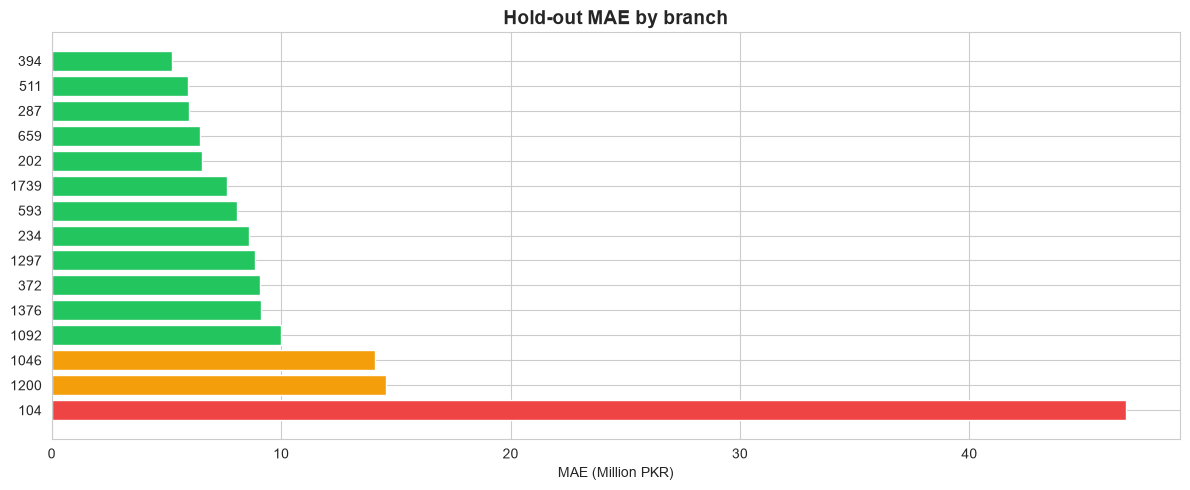

In [36]:
# 7.2 hold-out MAE by branch
fig, ax = plt.subplots(figsize=(12, 5))
sorted_br = branch_df.sort_values('MAE_M', ascending=True)
colors = ['#22c55e' if m < 10 else '#f59e0b' if m < 20 else '#ef4444' for m in sorted_br['MAE_M']]
ax.barh(sorted_br['Branch'].astype(str), sorted_br['MAE_M'], color=colors, edgecolor='white')
ax.set_xlabel('MAE (Million PKR)')
ax.set_title('Hold-out MAE by branch', fontsize=14, weight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [37]:
# 7.3 cash buffer per branch, with tiers from the 33rd and 66th percentiles of hold-out MAE
print('Cash buffer by branch (tiers from hold-out MAE)\n')

p33 = branch_df['MAE_M'].quantile(0.33)
p66 = branch_df['MAE_M'].quantile(0.66)

recommendations = []
for _, row in branch_df.iterrows():
    mape_v = row['MAPE_%']
    smape_v = row.get('SMAPE_%', 0.0)
    wmape_v = row.get('WMAPE_%', 0.0)
    mae  = row['MAE_M']
    avg  = row['Avg_Demand_M']

    if mae <= p33:
        buffer_pct, trust, action = 5,  'HIGH',     'Use model directly for replenishment'
    elif mae <= p66:
        buffer_pct, trust, action = 12, 'MEDIUM',   'Add safety buffer, monitor weekly'
    else:
        buffer_pct, trust, action = 20, 'LOW', 'Use with caution, manual override advised'

    safe_amount = avg * (1 + buffer_pct / 100)
    recommendations.append({
        'Branch': int(row['Branch']),
        'Avg_Demand_M': avg,
        'MAE_M': mae,
        'MAPE_%': mape_v,
        'SMAPE_%': smape_v,
        'WMAPE_%': wmape_v,
        'Trust_Level': trust,
        'Buffer_%': buffer_pct,
        'Recommended_M': round(safe_amount, 2),
        'Action': action,
    })

rec_df = pd.DataFrame(recommendations).sort_values('Avg_Demand_M', ascending=False)
print(rec_df[['Branch','Avg_Demand_M','MAE_M','MAPE_%','SMAPE_%','WMAPE_%','Trust_Level','Buffer_%','Recommended_M']].to_string(index=False))
print()
for _, r in rec_df.iterrows():
    print(f'  Branch {int(r["Branch"]):>5} -> {r["Action"]}')

Cash buffer by branch (tiers from hold-out MAE)

 Branch  Avg_Demand_M  MAE_M  MAPE_%  SMAPE_%  WMAPE_% Trust_Level  Buffer_%  Recommended_M
    104         83.77  46.84   211.8     66.6     55.9         LOW        20         100.52
   1200         32.47  14.56   253.4     55.2     44.8         LOW        20          38.96
   1046         32.09  14.11   106.5     53.9     44.0         LOW        20          38.51
   1297         28.52   8.86    67.7     39.7     31.1      MEDIUM        12          31.94
    234         24.78   8.59    90.5     49.3     34.7      MEDIUM        12          27.75
   1376         23.82   9.13   142.7     55.8     38.3         LOW        20          28.58
    202         22.14   6.57   100.7     49.0     29.7        HIGH         5          23.25
   1092         20.70   9.98   110.8     58.3     48.2         LOW        20          24.84
    372         18.03   9.10   146.7     63.6     50.5      MEDIUM        12          20.19
    659         16.62   6.47   

---
# 8. Explainability (SHAP)

Branch and treasury staff will only act on a forecast if they can see why it is high or low. SHAP splits each prediction into a contribution from every feature, so a forecast can be explained in terms such as "salary day", "high demand last week" or "afternoon slot".

In [38]:
# 8.1 SHAP values for the deployed ensemble
# The forecast is W_DEBIT * XGBoost + (1 - W_DEBIT) * LightGBM in log1p space. SHAP values are additive,
# so the same blend of the two models' SHAP values explains the ensemble. The check below confirms that
# base value + SHAP values reproduces the ensemble output for every sampled row.
W_DEBIT = cv_params['Half_Day_Total_Debit']['w_xgb']
print(f"Ensemble weights: XGBoost {W_DEBIT:.4f}, LightGBM {1 - W_DEBIT:.4f}")

X_test_sample = X_test.sample(n=min(200, len(X_test)), random_state=42)

explainer_xgb = shap.TreeExplainer(xgb_model)
explainer_lgb = shap.TreeExplainer(lgb_model)
sv_xgb = np.asarray(explainer_xgb.shap_values(X_test_sample))
sv_lgb = np.asarray(explainer_lgb.shap_values(X_test_sample))

shap_values = W_DEBIT * sv_xgb + (1 - W_DEBIT) * sv_lgb
base_value_blend = (W_DEBIT * float(explainer_xgb.expected_value)
                    + (1 - W_DEBIT) * float(explainer_lgb.expected_value))

# additivity check, in log1p space where the blend is done
recon = base_value_blend + shap_values.sum(axis=1)
actual = (W_DEBIT * xgb_model.predict(X_test_sample)
          + (1 - W_DEBIT) * lgb_model.predict(X_test_sample))
disc = np.abs(recon - actual)

TOL = 1e-4
assert disc.max() < TOL, f"SHAP values do not add up to the prediction: max difference {disc.max():.3e}"
print(f"\nAdditivity check on {len(disc)} hold-out rows: max difference {disc.max():.1e}, "
      f"mean {disc.mean():.1e} (tolerance {TOL:.0e})")
for nm, sv, ex, mdl in (('XGBoost', sv_xgb, explainer_xgb, xgb_model),
                        ('LightGBM', sv_lgb, explainer_lgb, lgb_model)):
    d = np.abs(float(ex.expected_value) + sv.sum(axis=1) - mdl.predict(X_test_sample))
    print(f"  {nm:<8} on its own: max difference {d.max():.1e}")

# Why log1p units: expm1 of a sum is not the sum of the expm1s, so converting each feature's
# contribution to PKR separately and adding them up would not give the predicted amount.
_pkr_direct = np.expm1(actual)
_pkr_naive = np.expm1(base_value_blend) + (np.expm1(base_value_blend + shap_values)
                                           - np.expm1(base_value_blend)).sum(axis=1)
_gap = np.median(np.abs(_pkr_naive - _pkr_direct) / np.maximum(_pkr_direct, 1)) * 100
print(f"\nConverting contributions to PKR one by one would be off by a median of {_gap:.1f}%, "
      f"so SHAP values are kept in log1p units.")

Ensemble weights: XGBoost 0.8000, LightGBM 0.2000



Additivity check on 200 hold-out rows: max difference 2.7e-05, mean 4.1e-06 (tolerance 1e-04)
  XGBoost  on its own: max difference 3.4e-05
  LightGBM on its own: max difference 3.6e-14

Converting contributions to PKR one by one would be off by a median of 15.6%, so SHAP values are kept in log1p units.


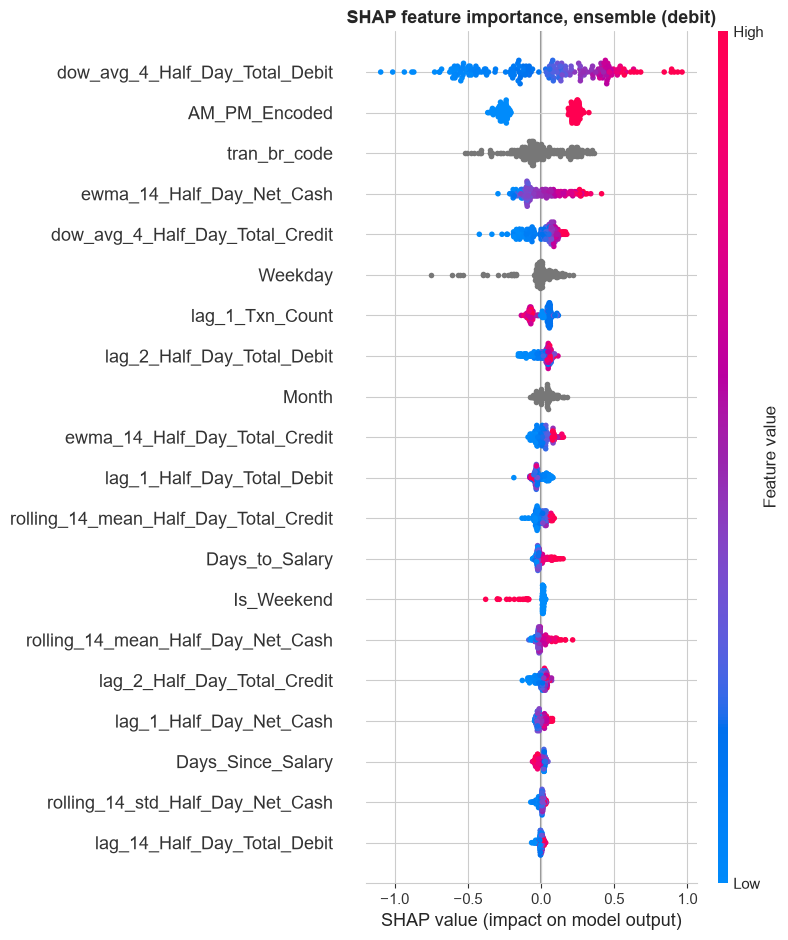

In [39]:
# 8.2 global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title('SHAP feature importance, ensemble (debit)', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

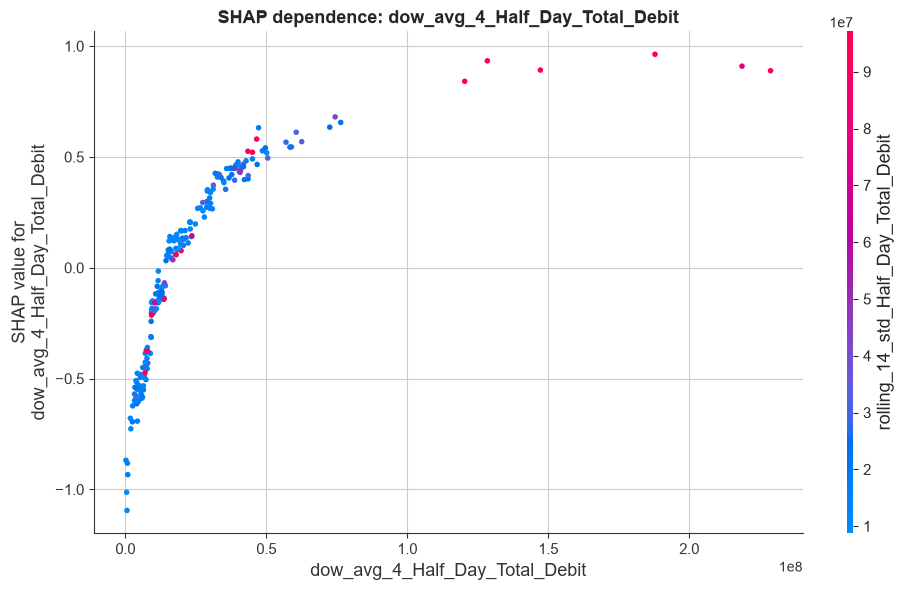

In [40]:
# 8.3 dependence plot for the most important feature
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_cols).sort_values(ascending=False)
top_feature = mean_shap.index[0]

fig, ax = plt.subplots(figsize=(10, 6))
shap.dependence_plot(top_feature, shap_values, X_test_sample, show=False, ax=ax)
ax.set_title(f'SHAP dependence: {top_feature}', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

Base value (log1p)     : 16.3936
Base + SHAP (log1p)    : 15.8307
Ensemble output (log1p): 15.8307
Prediction in PKR      : 7,502,453


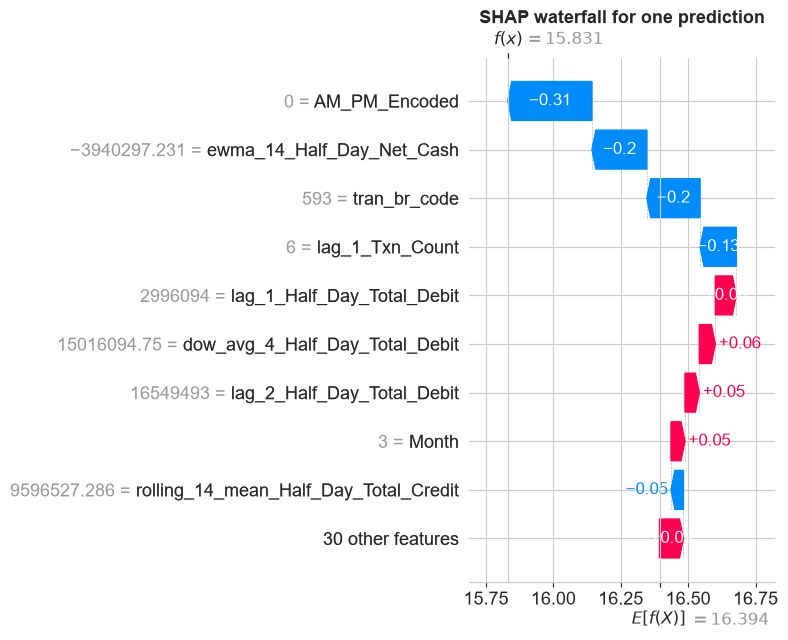

In [41]:
# 8.4 waterfall for one prediction (the first sampled hold-out row)
idx = 0
sample_row = X_test_sample.iloc[idx]
sample_shap = shap_values[idx]
base_value = base_value_blend

_row_actual = (W_DEBIT * xgb_model.predict(X_test_sample.iloc[[idx]])[0]
               + (1 - W_DEBIT) * lgb_model.predict(X_test_sample.iloc[[idx]])[0])
print(f"Base value (log1p)     : {base_value:.4f}")
print(f"Base + SHAP (log1p)    : {base_value + sample_shap.sum():.4f}")
print(f"Ensemble output (log1p): {_row_actual:.4f}")
print(f"Prediction in PKR      : {np.expm1(base_value + sample_shap.sum()):,.0f}")

shap_explanation = shap.Explanation(
    values=sample_shap,
    base_values=base_value,
    data=sample_row.values,
    feature_names=feature_cols
)
plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_explanation, show=False)
plt.title('SHAP waterfall for one prediction', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

**Reading the waterfall plot:** the bottom of the chart is the base value, the model's average output. Each bar shows how one feature moves this prediction up (red) or down (blue), and the top value is the final prediction. The units are log1p, so a bar of +0.1 means roughly 10% more cash rather than a fixed PKR amount.

---
# 9. 30-day forecast

The final ensemble is used to forecast the next 30 days for every branch. The forecast is recursive: each predicted half-day is added to the history and used as a lag for the next step, since the real values are not known yet.

Simplifications:
- For future days, credit is set to 90% of the predicted debit and the transaction count to the branch average; both are only needed as lag inputs.
- The 14-step EWMA features are approximated by a plain 14-step mean.
- The uncertainty band is ± the branch's hold-out MAPE from Section 7.1. Because MAPE is inflated on this data (Section 6), these bands are wide and the lower bound is often zero. The WMAPE-based bands from Step 6 of Section 7.0 are the better choice for the next version.
- Confidence is labelled HIGH for days 1 to 7, MEDIUM for days 8 to 14 and LOW after that.

In [42]:
# 9.1 setup
FORECAST_DAYS = 30
branches = sorted(half_daily['tran_br_code'].unique())
branch_avgs = half_daily.groupby('tran_br_code')['Txn_Count'].mean().to_dict()
last_date = half_daily['start_date'].max()

# per-branch hold-out MAPE (Section 7.1), used for the uncertainty bands
branch_mape_lookup = rec_df.set_index('Branch')['MAPE_%'].to_dict()

print(f"Branches: {branches}")
print(f"Last known date: {last_date.strftime('%Y-%m-%d')}")
print(f"Forecast period: {(last_date + pd.Timedelta(days=1)).strftime('%Y-%m-%d')} to {(last_date + pd.Timedelta(days=FORECAST_DAYS)).strftime('%Y-%m-%d')}")

Branches: [104, 202, 234, 287, 372, 394, 511, 593, 659, 1046, 1092, 1200, 1297, 1376, 1739]
Last known date: 2026-04-04
Forecast period: 2026-04-05 to 2026-05-04


In [43]:
# 9.2 calendar helpers
def is_salary_day(day):
    return 1 if day <= 5 or day >= 25 else 0

def is_holiday(date):
    return 1 if date in pk_holidays else 0

In [44]:
# 9.3 recursive forecast
W_DEBIT = cv_params['Half_Day_Total_Debit']['w_xgb']
print(f"Blend: XGBoost {W_DEBIT:.4f} / LightGBM {1 - W_DEBIT:.4f}")

# recent history per branch (65 rows is enough for lag_60)
working_history = (
    half_daily
    .sort_values(['tran_br_code', 'start_date', 'AM_PM'])
    .groupby('tran_br_code')
    .tail(65)
    .copy()
)
forecast_records = []
for step in range(1, FORECAST_DAYS + 1):
    target_date = last_date + pd.Timedelta(days=step)
    for branch in branches:
        br_hist = working_history[working_history['tran_br_code'] == branch]
        for am_pm, am_pm_enc in [('AM', 0), ('PM', 1)]:
            row = {
                'start_date': target_date,
                'tran_br_code': branch,
                'AM_PM': am_pm,
                'AM_PM_Encoded': am_pm_enc,
                'Weekday': target_date.weekday(),
                'Is_Weekend': 1 if target_date.weekday() >= 5 else 0,
                'Month': target_date.month,
                'Day': target_date.day,
                'Is_Salary_Day': is_salary_day(target_date.day),
                'Days_to_Salary': max(0, min(25, 25 - target_date.day if target_date.day < 25 else (31 - target_date.day + 5))),
                'Days_Since_Salary': target_date.day - 25 if target_date.day >= 25 else target_date.day + (31 - 25),
                'Is_Month_Start': 1 if target_date.day == 1 else 0,
                'Is_Month_End': 1 if (target_date + pd.Timedelta(days=1)).month != target_date.month else 0,
                'Is_Holiday': is_holiday(target_date),
            }
            # transaction-count features
            try:
                row['lag_1_Txn_Count'] = br_hist['Txn_Count'].iloc[-1]
                row['rolling_14_mean_Txn_Count'] = br_hist['Txn_Count'].tail(14).mean()
                row['ewma_14_Txn_Count'] = br_hist['Txn_Count'].tail(14).mean()  # EWMA approximated by the mean
            except IndexError:
                row['lag_1_Txn_Count'] = branch_avgs.get(branch, 0)
                row['rolling_14_mean_Txn_Count'] = branch_avgs.get(branch, 0)
                row['ewma_14_Txn_Count'] = branch_avgs.get(branch, 0)
            # lag and rolling features for each target
            for t_col in ['Half_Day_Total_Debit', 'Half_Day_Total_Credit', 'Half_Day_Net_Cash']:
                try:
                    row[f'lag_1_{t_col}']  = br_hist[t_col].iloc[-1]
                    row[f'lag_2_{t_col}']  = br_hist[t_col].iloc[-2]
                    row[f'lag_14_{t_col}'] = br_hist[t_col].iloc[-14]
                    row[f'lag_60_{t_col}'] = br_hist[t_col].iloc[-60]
                    row[f'rolling_14_mean_{t_col}'] = br_hist[t_col].tail(14).mean()
                    row[f'rolling_14_std_{t_col}'] = br_hist[t_col].tail(14).std() if len(br_hist[t_col]) > 1 else 0
                    row[f'ewma_14_{t_col}'] = br_hist[t_col].tail(14).mean()  # EWMA approximated by the mean
                    # dow_avg_4: last 4 half-days with the same weekday and AM/PM slot
                    same_slot = br_hist[(br_hist['Weekday'].astype(int) == target_date.weekday()) & (br_hist['AM_PM'] == am_pm)][t_col] if 'Weekday' in br_hist.columns else br_hist[t_col]
                    row[f'dow_avg_4_{t_col}'] = same_slot.tail(4).mean() if len(same_slot) > 0 else row[f'rolling_14_mean_{t_col}']
                except IndexError:
                    for sfx in ['lag_1', 'lag_2', 'lag_14', 'lag_60', 'rolling_14_mean', 'rolling_14_std', 'ewma_14', 'dow_avg_4']:
                        row[f'{sfx}_{t_col}'] = 0
            # predict with the ensemble
            x_df = pd.DataFrame([row])[feature_cols]
            x_df['tran_br_code'] = x_df['tran_br_code'].astype('category')
            x_df['Weekday'] = x_df['Weekday'].astype('category')
            x_df['Month'] = x_df['Month'].astype('category')
            pred_log = W_DEBIT * xgb_model.predict(x_df)[0] + (1 - W_DEBIT) * lgb_model.predict(x_df)[0]
            pred_dr = max(0, np.expm1(pred_log))
            # add the prediction to the history so later steps can use it as a lag
            row['Half_Day_Total_Debit']  = pred_dr
            row['Half_Day_Total_Credit'] = pred_dr * 0.9   # rough assumption, only used as a lag input
            row['Half_Day_Net_Cash']     = row['Half_Day_Total_Credit'] - pred_dr
            row['Txn_Count']             = branch_avgs.get(branch, 0)
            forecast_records.append(row)
            hist_row = pd.DataFrame([row])
            working_history = pd.concat([working_history, hist_row], ignore_index=True)
            working_history = working_history.groupby('tran_br_code').tail(65)
fc_half_daily = pd.DataFrame(forecast_records)
print(f"Forecast generated: {len(fc_half_daily)} half-daily records for {len(branches)} branches x {FORECAST_DAYS} days")

Blend: XGBoost 0.8000 / LightGBM 0.2000


Forecast generated: 900 half-daily records for 15 branches x 30 days


In [45]:
# 9.4 daily totals and uncertainty bands
fc_daily = fc_half_daily.groupby(['start_date', 'tran_br_code']).agg(
    Predicted_PKR=('Half_Day_Total_Debit', 'sum')
).reset_index()
fc_daily = fc_daily.rename(columns={'start_date': 'Date', 'tran_br_code': 'Branch'})
fc_daily['Step'] = (fc_daily['Date'] - last_date).dt.days
fc_daily['Predicted_M'] = (fc_daily['Predicted_PKR'] / 1e6).round(2)

# band: +/- the branch's hold-out MAPE
def add_uncertainty(row):
    mape_val = branch_mape_lookup.get(int(row['Branch']), 30.0)
    pct = mape_val / 100.0
    pred = row['Predicted_M']
    step = row['Step']
    conf = 'HIGH' if step <= 7 else ('MEDIUM' if step <= 14 else 'LOW')
    return pd.Series({
        'Lower_M': round(max(0.0, pred * (1 - pct)), 2),
        'Upper_M': round(pred * (1 + pct), 2),
        'Uncertainty_%': round(pct * 100, 1),
        'Confidence': conf,
    })

fc_daily[['Lower_M', 'Upper_M', 'Uncertainty_%', 'Confidence']] = fc_daily.apply(add_uncertainty, axis=1)

print("Daily forecast with uncertainty bounds:")
fc_daily[['Branch','Date','Predicted_M','Lower_M','Upper_M','Confidence']].head(10)

Daily forecast with uncertainty bounds:


,Branch,Date,Predicted_M,Lower_M,Upper_M,Confidence
0,104,2026-04-05,103.15,0.00,321.62,HIGH
1,202,2026-04-05,16.78,0.00,33.68,HIGH
2,234,2026-04-05,20.82,1.98,39.66,HIGH
3,287,2026-04-05,5.15,0.00,17.22,HIGH
4,372,2026-04-05,15.22,0.00,37.55,HIGH
5,394,2026-04-05,14.06,6.69,21.43,HIGH
6,511,2026-04-05,13.48,0.00,31.38,HIGH
7,593,2026-04-05,14.61,0.00,37.81,HIGH
8,659,2026-04-05,10.47,0.00,25.82,HIGH
9,1046,2026-04-05,52.05,0.00,107.48,HIGH


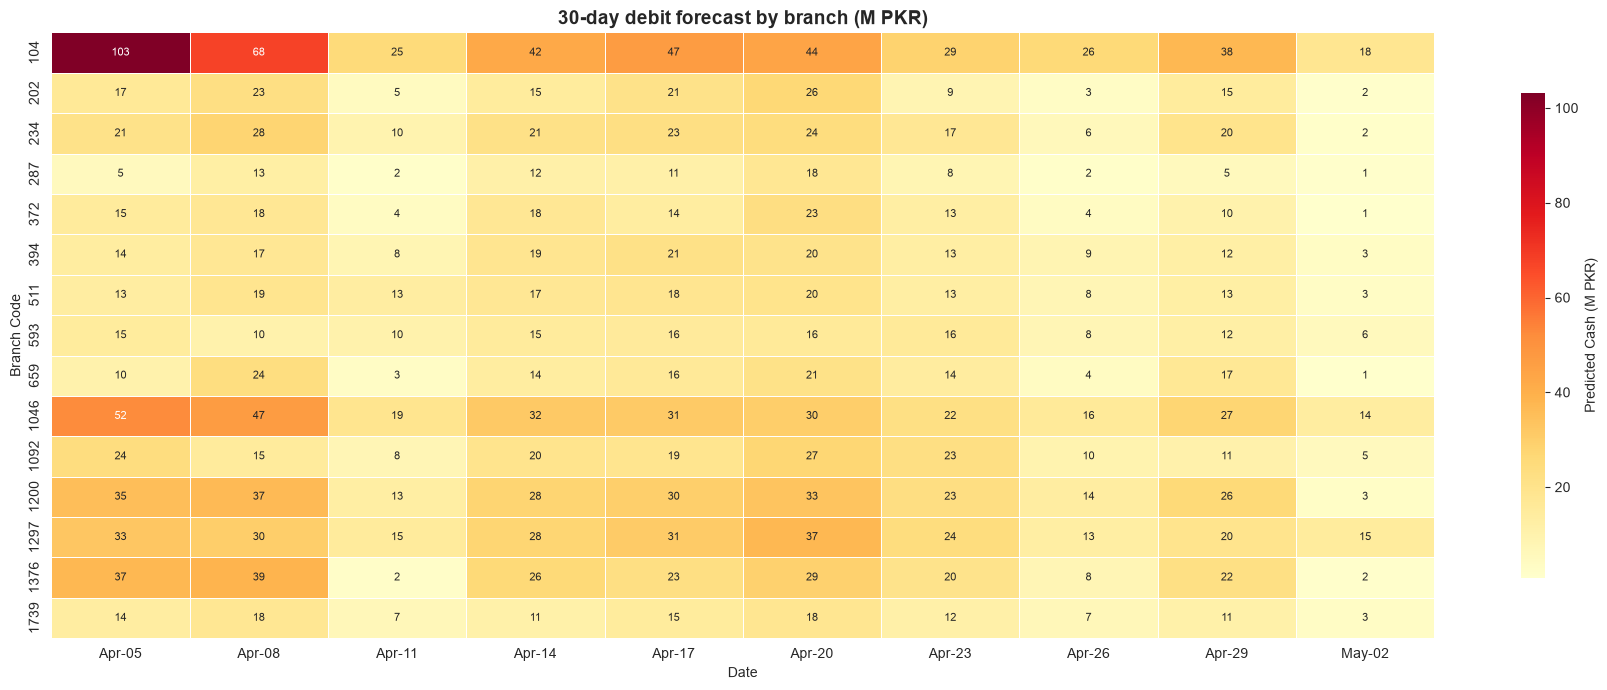

In [46]:
# 9.5 forecast heatmap (every third day shown)
heat_pivot = fc_daily.pivot_table(index='Branch', columns='Date', values='Predicted_M')
heat_pivot.columns = [d.strftime('%b-%d') for d in heat_pivot.columns]
heat_pivot.index = heat_pivot.index.astype(str)

col_mask = [i % 3 == 0 for i in range(len(heat_pivot.columns))]
heat_display = heat_pivot.iloc[:, col_mask]

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(
    heat_display, ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
    linewidths=0.5, annot_kws={'size': 8},
    cbar_kws={'label': 'Predicted Cash (M PKR)', 'shrink': 0.8}
)
ax.set_title('30-day debit forecast by branch (M PKR)', fontsize=14, weight='bold')
ax.set_ylabel('Branch Code')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

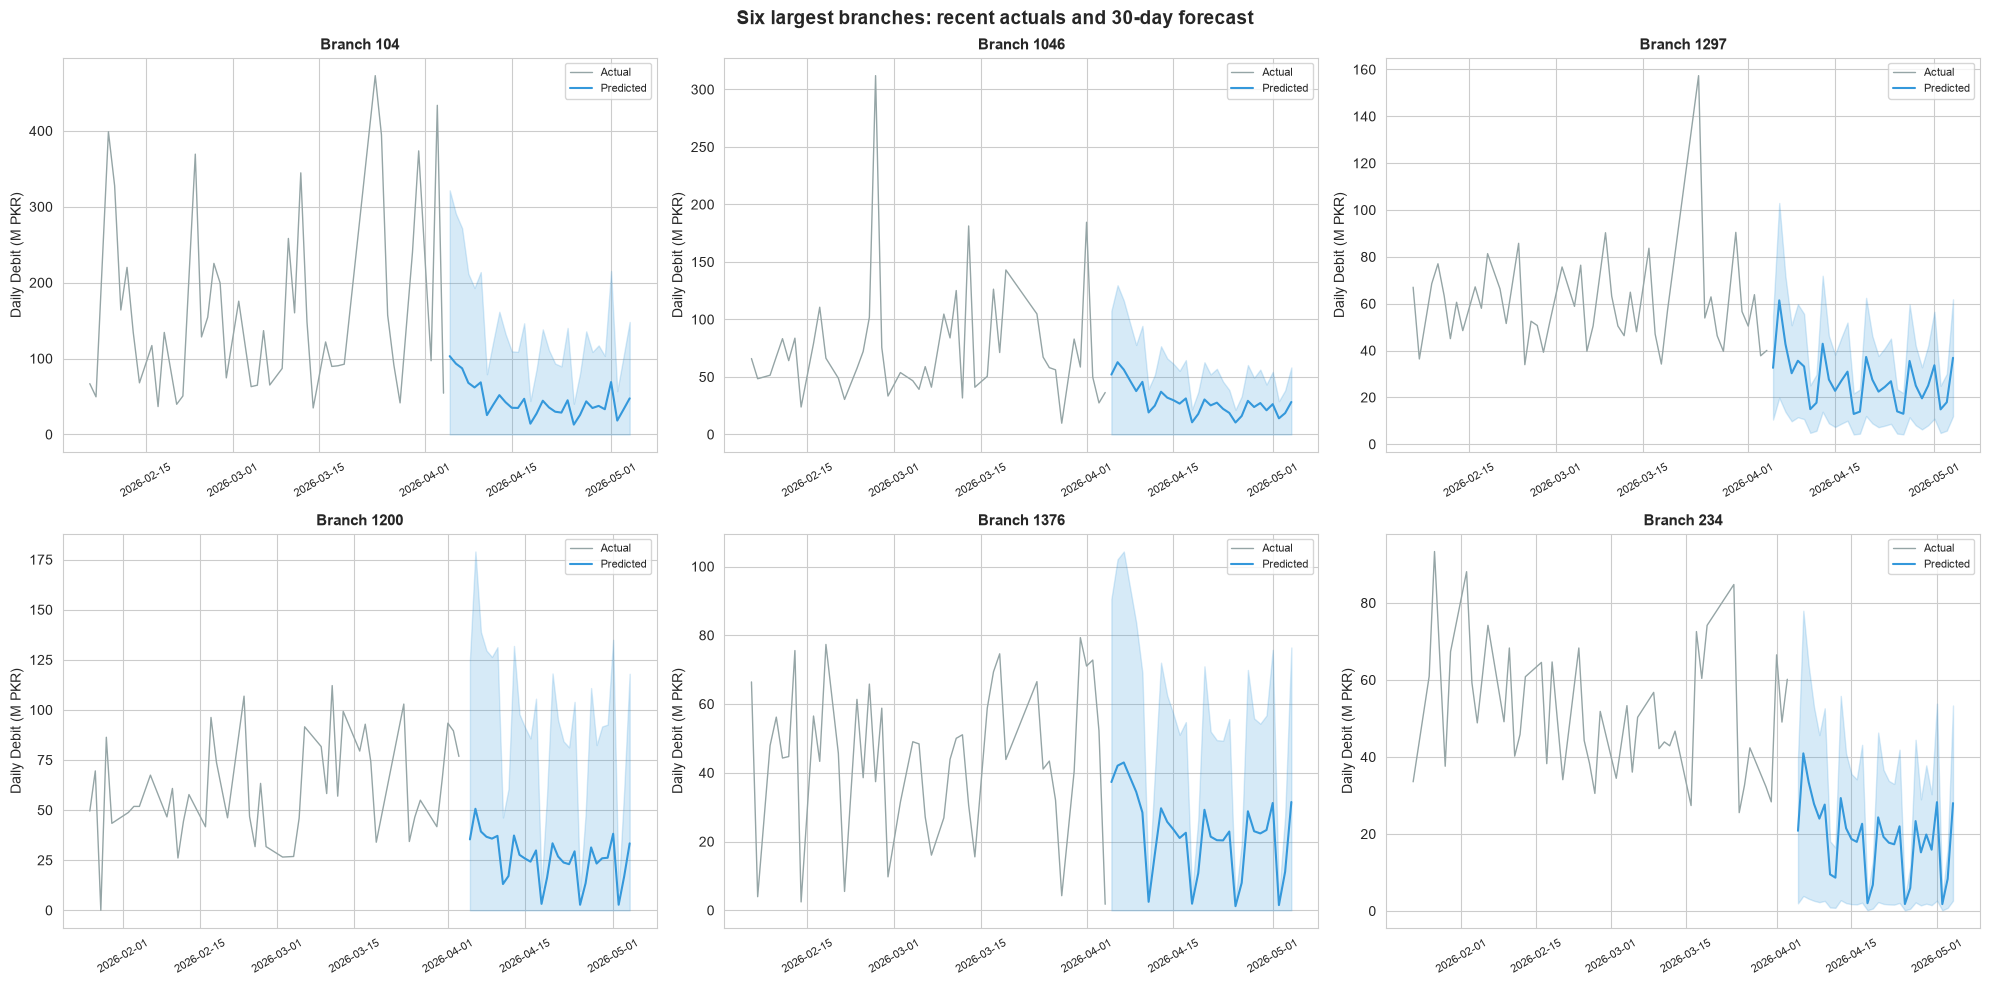

In [47]:
# 9.6 six largest branches: last 45 days of actuals and the 30-day forecast
top_branches = fc_daily.groupby('Branch')['Predicted_M'].mean().nlargest(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
fig.suptitle('Six largest branches: recent actuals and 30-day forecast',
             fontsize=14, weight='bold')

for idx, branch in enumerate(top_branches):
    ax = axes.flatten()[idx]

    br_hist_plot = half_daily[half_daily['tran_br_code'] == branch].copy()
    br_hist_daily = br_hist_plot.groupby('start_date')['Half_Day_Total_Debit'].sum() / 1e6
    br_hist_daily = br_hist_daily.tail(45)
    ax.plot(br_hist_daily.index, br_hist_daily.values, color='#95a5a6', linewidth=1, label='Actual')

    br_fc = fc_daily[fc_daily['Branch'] == branch].sort_values('Date')
    ax.plot(br_fc['Date'], br_fc['Predicted_M'], color='#3498db', linewidth=1.5, label='Predicted')
    ax.fill_between(br_fc['Date'], br_fc['Lower_M'], br_fc['Upper_M'], alpha=0.2, color='#3498db')

    ax.set_title(f'Branch {branch}', fontsize=11, weight='bold')
    ax.set_ylabel('Daily Debit (M PKR)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30, labelsize=8)

plt.tight_layout()
plt.show()

In [48]:
# 9.7 weekly summary
def week_label(step):
    if step <= 7:  return 'Week1'
    if step <= 14: return 'Week2'
    if step <= 21: return 'Week3'
    return 'Week4'

fc_daily['Week'] = fc_daily['Step'].apply(week_label)

weekly = (
    fc_daily.groupby(['Branch', 'Week'])['Predicted_M']
    .agg(['mean', 'sum'])
    .round(1)
    .rename(columns={'mean': 'Daily_Avg_M', 'sum': 'Week_Total_M'})
    .reset_index()
)

weekly_pivot = weekly.pivot_table(
    index='Branch', columns='Week', values='Daily_Avg_M'
)

col_order = ['Week1', 'Week2', 'Week3', 'Week4']
weekly_pivot = weekly_pivot[[c for c in col_order if c in weekly_pivot.columns]]

# trust level from Section 7.3
trust_map = dict(zip(rec_df['Branch'], rec_df['Trust_Level']))
weekly_pivot['Trust_Level'] = weekly_pivot.index.map(trust_map)

print('Average daily forecast per week (M PKR), with the trust level from 7.3:')
print(weekly_pivot.to_string())
print(f'\nTotal network cash required (30 days): {fc_daily["Predicted_M"].sum():.1f} M PKR')

Average daily forecast per week (M PKR), with the trust level from 7.3:
Week    Week1  Week2  Week3  Week4 Trust_Level
Branch                                        
104      72.5   37.8   32.0   38.1         LOW
202      22.8   14.7   13.0   13.7        HIGH
234      26.3   17.2   15.6   16.3      MEDIUM
287      11.8    9.7    7.2    8.2        HIGH
372      16.1   13.3   11.6   11.9      MEDIUM
394      18.7   15.1   13.4   14.3        HIGH
511      20.6   14.1   12.9   14.1        HIGH
593      17.4   14.9   12.7   14.3      MEDIUM
659      17.7   13.7   11.9   13.0        HIGH
1046     45.8   27.5   21.8   22.7         LOW
1092     23.6   16.8   15.4   16.6         LOW
1200     35.4   23.6   22.2   23.5         LOW
1297     35.8   26.0   23.8   24.6      MEDIUM
1376     32.4   20.1   18.0   20.1         LOW
1739     17.8   11.5   10.3   11.0      MEDIUM

Total network cash required (30 days): 8889.5 M PKR
